In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'data').exists():
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

for candidate in [
    PROJECT_ROOT / 'code',
    PROJECT_ROOT / 'code' / 'revenue',
    PROJECT_ROOT / 'code' / 'tmdb',
]:
    if candidate.exists() and str(candidate.resolve()) not in sys.path:
        sys.path.append(str(candidate.resolve()))

import ast
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

IMAGES_DIR = PROJECT_ROOT / 'code' / 'tmdb' / 'images'
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

ARTICLE_NOTEBOOK_DPI = 170
ARTICLE_EXPORT_DPI = 320

def build_image_path(title):
    normalized = unicodedata.normalize('NFKD', title).encode('ascii', 'ignore').decode('ascii')
    slug = ''.join(char.lower() if char.isalnum() else '_' for char in normalized)
    slug = '_'.join(part for part in slug.split('_') if part)
    return IMAGES_DIR / f'{slug}.png'

def save_current_figure(title, dpi=ARTICLE_EXPORT_DPI):
    image_path = build_image_path(title)
    plt.savefig(image_path, dpi=dpi, bbox_inches='tight')
    return image_path

ARTICLE_FIGURE_SIZES = {
    'axis_label': 22,
    'tick': 18,
    'annotation': 18,
}
ARTICLE_FIGURE_RC = {
    'axes.labelsize': ARTICLE_FIGURE_SIZES['axis_label'],
    'xtick.labelsize': ARTICLE_FIGURE_SIZES['tick'],
    'ytick.labelsize': ARTICLE_FIGURE_SIZES['tick'],
    'figure.dpi': ARTICLE_NOTEBOOK_DPI,
    'savefig.dpi': ARTICLE_EXPORT_DPI,
}

def apply_article_figure_theme():
    sns.set_theme(style='whitegrid', context='talk', rc=ARTICLE_FIGURE_RC)

def show_and_save_current_figure(title, notebook_title=None, dpi=ARTICLE_EXPORT_DPI):
    if notebook_title:
        print(f'Figura: {notebook_title}')
    image_path = save_current_figure(title, dpi=dpi)
    plt.show()
    plt.close()
    return image_path

# **Carregando a Base de Dados**

Neste notebook, a base bruta coletada a partir da API do TMDB é carregada, inspecionada e preparada para análise. Ele funciona como a ponte entre a etapa de coleta e a etapa de regressão, reunindo limpeza, análise exploratória e transformação das variáveis em um fluxo único e reproduzível.

Além da leitura do arquivo `.csv`, alguns campos originalmente armazenados como texto estruturado, como `genres` e `belongs_to_collection`, são convertidos para objetos Python. Isso permite manipular essas informações de forma consistente tanto na exploração inicial quanto na construção do conjunto final usado pelos modelos.


## **Descrição dos Atributos da Base de Dados**

A base carregada neste notebook corresponde ao conjunto bruto obtido na etapa de coleta. Os atributos abaixo resumem as informações inicialmente disponíveis para cada filme e ajudam a justificar, nas seções seguintes, tanto as filtragens aplicadas quanto a seleção das variáveis mantidas para regressão.

| Atributo | Descrição |
|----------|-----------|
| `id_tmdb` | Identificador único do filme na base de dados do TMDB. |
| `title` | Título original do filme, sem tradução. |
| `original_language` | Código do idioma original do filme, como `'en'` para inglês ou `'pt'` para português. |
| `adult` | Indicador booleano que informa se a obra está marcada como conteúdo adulto. |
| `video` | Indicador booleano que informa se a entrada representa um vídeo, como trailer ou clipe, e não propriamente um filme. |
| `genres` | Lista de gêneros associados ao filme, retornada como uma lista de dicionários contendo identificador e nome de cada gênero. |
| `status` | Situação de lançamento da obra na base, como `'Released'` ou `'Post Production'`. |
| `runtime` | Duração do filme em minutos. |
| `belongs_to_collection` | Informação sobre a franquia ou coleção da qual o filme faz parte, quando essa informação existir. |
| `budget` | Orçamento estimado de produção do filme, em dólares americanos. |
| `revenue` | Receita mundial total arrecadada pelo filme, também em dólares americanos. |


In [2]:
def parse_json_column(value):
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return None
    
df = pd.read_csv(PROJECT_ROOT / 'data' / 'TMDB_movies_original.csv')  
df['genres'] = df['genres'].apply(parse_json_column)
df['belongs_to_collection'] = df['belongs_to_collection'].apply(parse_json_column)
df

,id_tmdb,title,original_language,adult,video,genres,status,runtime,belongs_to_collection,budget,revenue
0,552524,Lilo & Stitch,en,False,False,"[{'id': 10751, 'name': 'Family'}, {'id': 35, '...",Released,108,None,100000000,610800000
1,950387,A Minecraft Movie,en,False,False,"[{'id': 10751, 'name': 'Family'}, {'id': 35, '...",Released,101,"{'id': 1461530, 'name': 'The Minecraft Movie C...",150000000,947000000
2,1257960,सिकंदर,hi,False,False,"[{'id': 28, 'name': 'Action'}, {'id': 18, 'nam...",Released,133,None,23500000,24727058
3,574475,Final Destination Bloodlines,en,False,False,"[{'id': 27, 'name': 'Horror'}, {'id': 9648, 'n...",Released,110,"{'id': 8864, 'name': 'Final Destination Collec...",50000000,229314062
4,1197306,A Working Man,en,False,False,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",Released,116,None,40000000,98652557
...,...,...,...,...,...,...,...,...,...,...,...
19995,456048,The Humanity Bureau,en,False,False,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",Released,94,None,6000000,17544173
19996,889,The Flintstones in Viva Rock Vegas,en,False,False,"[{'id': 35, 'name': 'Comedy'}, {'id': 10751, '...",Released,90,"{'id': 351684, 'name': 'The Flintstones Collec...",83000000,59468275
19997,412547,Killing Gunther,en,False,False,"[{'id': 28, 'name': 'Action'}, {'id': 35, 'nam...",Released,93,None,0,197616
19998,74997,The Human Centipede 2 (Full Sequence),en,False,False,"[{'id': 18, 'name': 'Drama'}, {'id': 27, 'name...",Released,91,"{'id': 96671, 'name': 'The Human Centipede Col...",0,170323


# **Removendo informações desnecessárias**

Antes de qualquer modelagem, a base precisa passar por um processo de limpeza. Nesta etapa, são eliminados registros duplicados, entradas com informação insuficiente e casos que não fazem sentido para o problema estudado, de modo a obter um conjunto mais consistente para análise e regressão.

O objetivo não é apenas reduzir ruído, mas alinhar o dataset ao problema real de predição de receita: filmes lançados, com informações mínimas confiáveis e variáveis com significado prático dentro da tarefa.


## **Removendo linhas duplicadas**

Como a coleta foi feita a partir de mais de uma listagem da API, o mesmo filme pode aparecer repetidamente. Por isso, a primeira limpeza consiste em remover registros duplicados com base no identificador `id_tmdb`, garantindo que cada obra apareça apenas uma vez no conjunto.

Sem essa etapa, contagens, distribuições e métricas posteriores poderiam ficar artificialmente distorcidas pela repetição de observações equivalentes.


In [3]:
filtered_df = df.drop_duplicates(subset='id_tmdb')
filtered_df.shape[0]

13767

## **Removendo linhas incompletas**

Nesta etapa, são removidos registros completamente vazios nas colunas analisadas, desconsiderando `belongs_to_collection` nesse critério. Essa exceção é adotada porque um valor nulo nessa coluna pode apenas indicar que o filme não pertence a nenhuma franquia ou coleção, enquanto os demais critérios de consistência são refinados nas filtragens aplicadas em seguida.

A ideia é diferenciar ausência estrutural de informação útil de ausência que, na prática, inviabiliza a análise do filme dentro do problema estudado.


In [4]:
filtered_df = filtered_df.dropna(
    how='all',
    subset=[col for col in filtered_df.columns if col != 'belongs_to_collection']
)
print(filtered_df.shape[0])

13767


## **Removendo dados irrelevantes**

Após a remoção de duplicatas e a verificação de campos ausentes, é aplicada uma filtragem voltada especificamente ao problema de predição de receita. São mantidos apenas filmes com `budget`, `revenue` e `runtime` maiores que zero, pois esses atributos são fundamentais para a análise e sua ausência comprometeria a utilidade do registro.

Além disso, são excluídas entradas classificadas como `video`, como trailers e clipes, bem como registros sem gêneros informados. Por fim, são preservados apenas os títulos com status `Released`, já que obras ainda não lançadas ou em produção não são adequadas para a comparação de receita efetivamente arrecadada.

Esses filtros tornam a base mais coerente com a interpretação econômica da variável-alvo e evitam que o modelo aprenda a partir de registros que não representam lançamentos cinematográficos comparáveis entre si.


In [5]:
filtered_df = filtered_df[
    (filtered_df['budget'] > 0) &
    (filtered_df['revenue'] > 0) &
    (filtered_df['runtime'] > 0) &
    (filtered_df['genres'].apply(lambda x: isinstance(x, list) and len(x) > 0)) &
    (filtered_df['video'] == False) &
    (filtered_df['status'] == 'Released')
]

print(filtered_df.shape[0])

6918


# **Análise do Dataset**

Com a base já filtrada, passa-se à etapa de análise exploratória. O objetivo aqui é examinar a distribuição dos principais atributos, identificar padrões gerais do conjunto e produzir evidências que ajudem a entender melhor o comportamento dos dados antes da modelagem.

Essa leitura é importante para antecipar desequilíbrios, assimetrias e limitações que podem afetar tanto a escolha dos algoritmos quanto a interpretação dos resultados obtidos depois.


Cada atributo relevante será analisado individualmente, combinando contagens, estatísticas descritivas e visualizações gráficas. Essa etapa ajuda a compreender a composição da base e a identificar possíveis desequilíbrios, concentrações ou limitações dos dados disponíveis.

Sempre que possível, a interpretação já é direcionada para a utilidade da variável no problema de regressão, e não apenas para uma descrição genérica do dataset.


## **Códigos auxiliares**

As funções definidas a seguir padronizam a geração de tabelas descritivas e gráficos utilizados ao longo da análise. Além de evitar repetição de código e manter consistência visual entre as visualizações, elas também salvam automaticamente as figuras na pasta `code/tmdb/images`, facilitando seu reaproveitamento no relatório.

Essa padronização também reduz o risco de interpretações inconsistentes causadas por mudanças arbitrárias de escala, estilo ou formatação entre gráficos semelhantes.


In [6]:
def plot_value_counts(data, type_data, title):
    import seaborn as sns
    import matplotlib.pyplot as plt

    apply_article_figure_theme()
    n_bars = data.shape[0]
    if n_bars > 20:
        data = data.iloc[:20]
        n_bars = 20

    if n_bars <= 2:
        width, height = 10.4, 6.9
        title_size = 25
        label_size = ARTICLE_FIGURE_SIZES['axis_label']
        tick_size = ARTICLE_FIGURE_SIZES['tick']
        annotation_size = ARTICLE_FIGURE_SIZES['annotation']
    elif n_bars <= 5:
        width = max(11.8, n_bars * 2.15)
        height = max(7.0, width * 0.52)
        title_size = 25
        label_size = ARTICLE_FIGURE_SIZES['axis_label']
        tick_size = ARTICLE_FIGURE_SIZES['tick']
        annotation_size = ARTICLE_FIGURE_SIZES['annotation']
    else:
        width = max(18, n_bars * 1.14)
        height = max(9.2, width * 0.54)
        title_size = 30
        label_size = ARTICLE_FIGURE_SIZES['axis_label'] + 1
        tick_size = ARTICLE_FIGURE_SIZES['tick'] + 1
        annotation_size = ARTICLE_FIGURE_SIZES['annotation'] + 1

    plt.figure(figsize=(width, height))
    palette = sns.color_palette("crest", n_bars)

    ax = sns.barplot(
        data=data,
        x=type_data,
        y='Frequência',
        hue=type_data,
        dodge=False,
        palette=palette,
        legend=False,
        width=0.45 if n_bars < 3 else 0.74,
        edgecolor='#243746',
        linewidth=0.8
    )

    ax.set_xlabel(type_data, fontsize=label_size, fontweight='semibold', labelpad=12)
    ax.set_ylabel('Frequência', fontsize=label_size, fontweight='semibold', labelpad=12)
    ax.tick_params(axis='x', labelsize=tick_size)
    ax.tick_params(axis='y', labelsize=tick_size)
    plt.xticks(rotation=48 if n_bars > 5 else 0, ha='right' if n_bars > 5 else 'center')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('semibold')

    if n_bars > 15:
        ax.set_yscale('log')

    if n_bars < 3:
        ax.set_xlim(-0.5, n_bars - 0.5 + 0.5)

    ax.grid(axis='y', linestyle='--', alpha=0.28)
    sns.despine(ax=ax, left=False, bottom=False)

    for i, valor in enumerate(data['Frequência']):
        ax.text(
            i,
            valor + 0.5 if ax.get_yscale() != 'log' else valor * 1.08,
            str(valor),
            ha='center',
            va='bottom',
            fontsize=annotation_size,
            fontweight='semibold',
            color='#243746'
        )

    plt.tight_layout()
    show_and_save_current_figure(title, notebook_title=title)

In [7]:
def plot_boxplot(df, column_name, title, xlabel):
    apply_article_figure_theme()
    plt.figure(figsize=(13, 6.4))

    ax = sns.boxplot(
        x=df[column_name],
        color='#89a8b2',
        linewidth=1.8,
        fliersize=4,
        boxprops=dict(edgecolor='#1f2d3a'),
        medianprops=dict(color='#8c1c13', linewidth=2.2),
        whiskerprops=dict(color='#1f2d3a', linewidth=1.5),
        capprops=dict(color='#1f2d3a', linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor='#8c1c13', markeredgecolor='#8c1c13', alpha=0.55)
    )

    ax.set_xlabel(xlabel, fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=12)
    ax.set_ylabel('')

    ax.tick_params(axis='x', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    ax.tick_params(axis='y', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('semibold')
    ax.grid(True, axis='x', linestyle='--', alpha=0.3)
    sns.despine(ax=ax, left=True, bottom=False)

    plt.tight_layout()
    show_and_save_current_figure(title, notebook_title=title)

In [8]:
def plot_distribution(df, name_column, title, xlabel):
    apply_article_figure_theme()
    plt.figure(figsize=(13, 7.4))

    ax = sns.histplot(
        df[name_column],
        bins=24,
        kde=True,
        color='#4c6a92',
        edgecolor='white',
        linewidth=0.9,
        alpha=0.9,
        line_kws={'linewidth': 2.4, 'color': '#8c1c13'}
    )

    ax.set_xlabel(xlabel, fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=12)
    ax.set_ylabel('Número de Filmes', fontsize=ARTICLE_FIGURE_SIZES['axis_label'], fontweight='semibold', labelpad=12)

    xmin = df[name_column].min()
    xmax = df[name_column].max()

    xticks = np.linspace(xmin, xmax, 10)
    ax.set_xticks(xticks)
    ax.tick_params(axis='x', labelsize=ARTICLE_FIGURE_SIZES['tick'])

    ax.tick_params(axis='y', labelsize=ARTICLE_FIGURE_SIZES['tick'])
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('semibold')
    ax.grid(True, linestyle='--', alpha=0.28)
    sns.despine(ax=ax)

    plt.tight_layout()
    show_and_save_current_figure(title, notebook_title=title)

In [9]:
def describe_column(df, column_name, description_name=None):
    desc = df[column_name].describe().to_frame().T
    if description_name is None:
        description_name = f'Statistics for {column_name}'
    desc.index = [description_name]
    return desc

## **Atributo: original_language**

A coluna `original_language` permite observar a diversidade linguística da base e identificar quais idiomas concentram a maior parte dos filmes coletados. Essa análise é útil para verificar se há predominância de determinadas indústrias cinematográficas no conjunto e se a variável tende a carregar um sinal relevante sobre contexto de mercado.


Figura: Distribuição dos Idiomas Originais


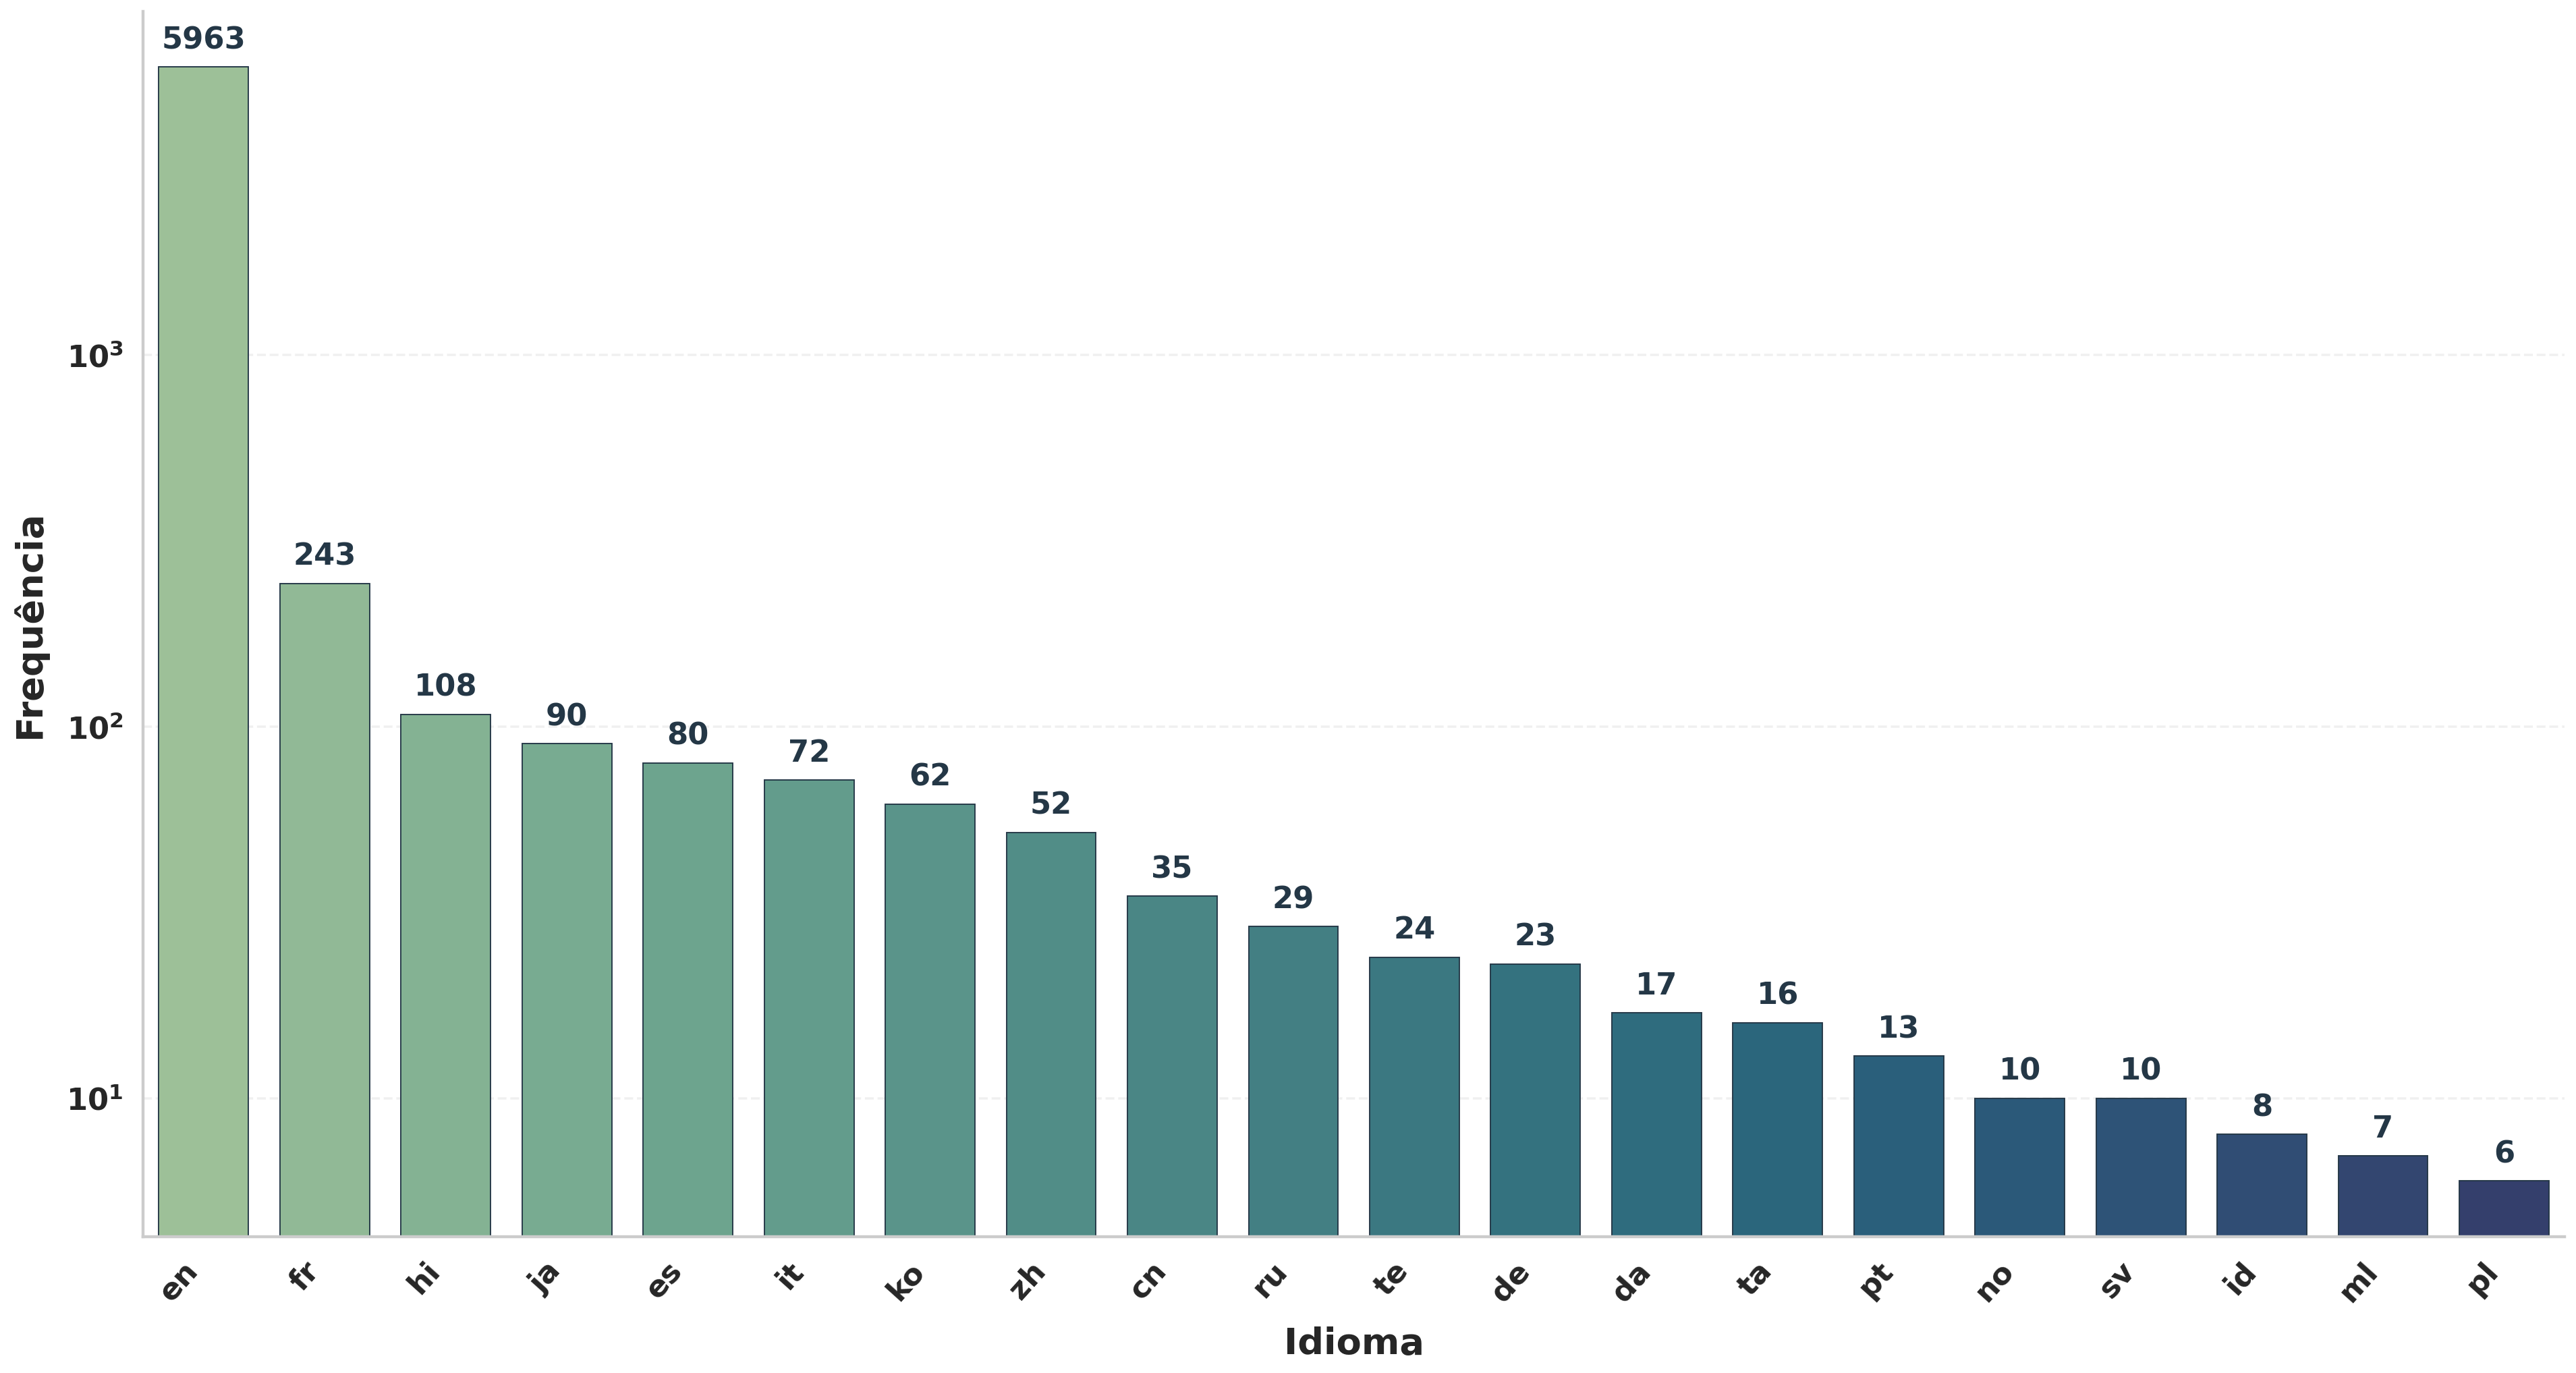

In [10]:
language_count = filtered_df['original_language'].value_counts().reset_index()
language_count.columns = ['Idioma', 'Frequência']

plot_value_counts(language_count, 'Idioma', 'Distribuição dos Idiomas Originais')

In [11]:
print(f'Total de idiomas originais: {language_count.shape[0]}')

Total de idiomas originais: 47


## **Atributo: adult**

O atributo `adult` indica se a obra foi classificada como conteúdo adulto. Como a análise é feita sobre a base já filtrada, essa inspeção serve principalmente para verificar se ainda restou variação nessa coluna após as etapas de limpeza.


Figura: Distribuição de Conteúdo Adulto


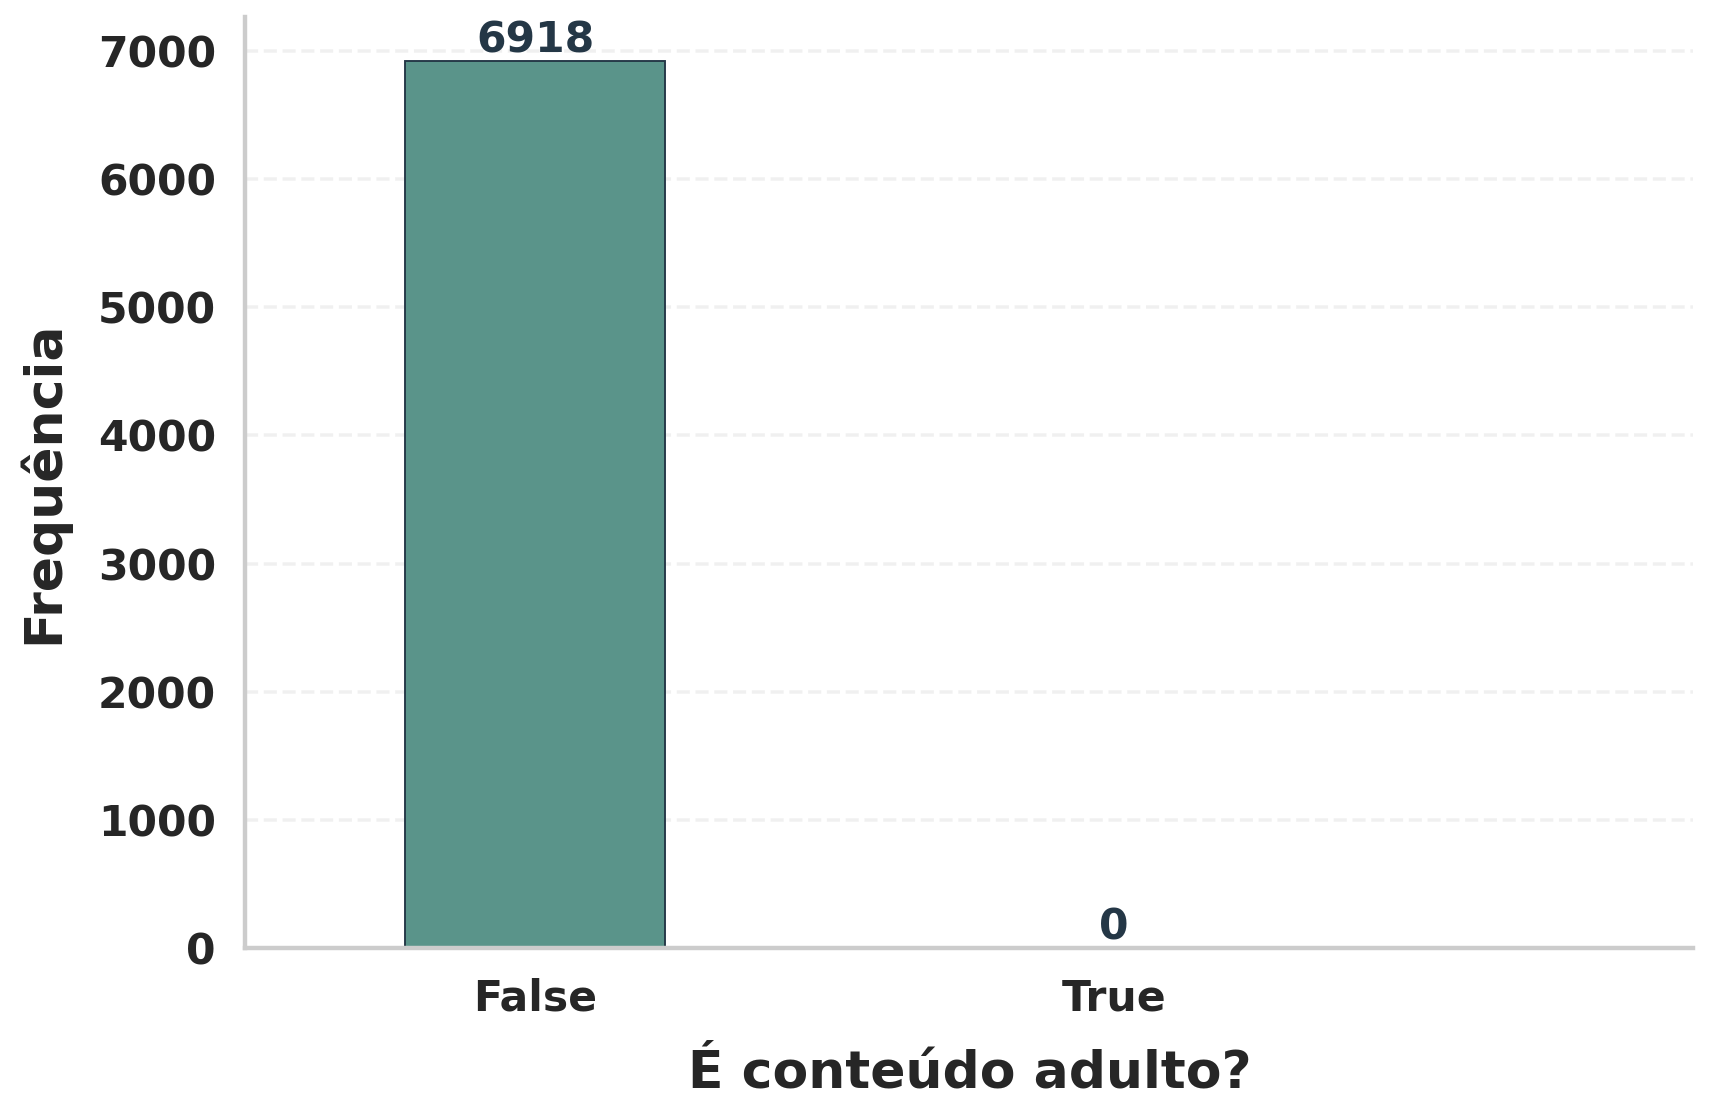

In [12]:
adult_count = filtered_df['adult'].value_counts().reindex([False, True], fill_value=0).reset_index()
adult_count.columns = ['É conteúdo adulto?', 'Frequência']

plot_value_counts(adult_count, 'É conteúdo adulto?', 'Distribuição de Conteúdo Adulto')

## **Atributo: video**

Como a filtragem anterior já removeu entradas com `video = True`, a análise de `video` atua principalmente como uma checagem de consistência do conjunto final, confirmando a ausência de trailers, clipes e outros registros que não correspondem propriamente a filmes.


Figura: Distribuição de Vídeos


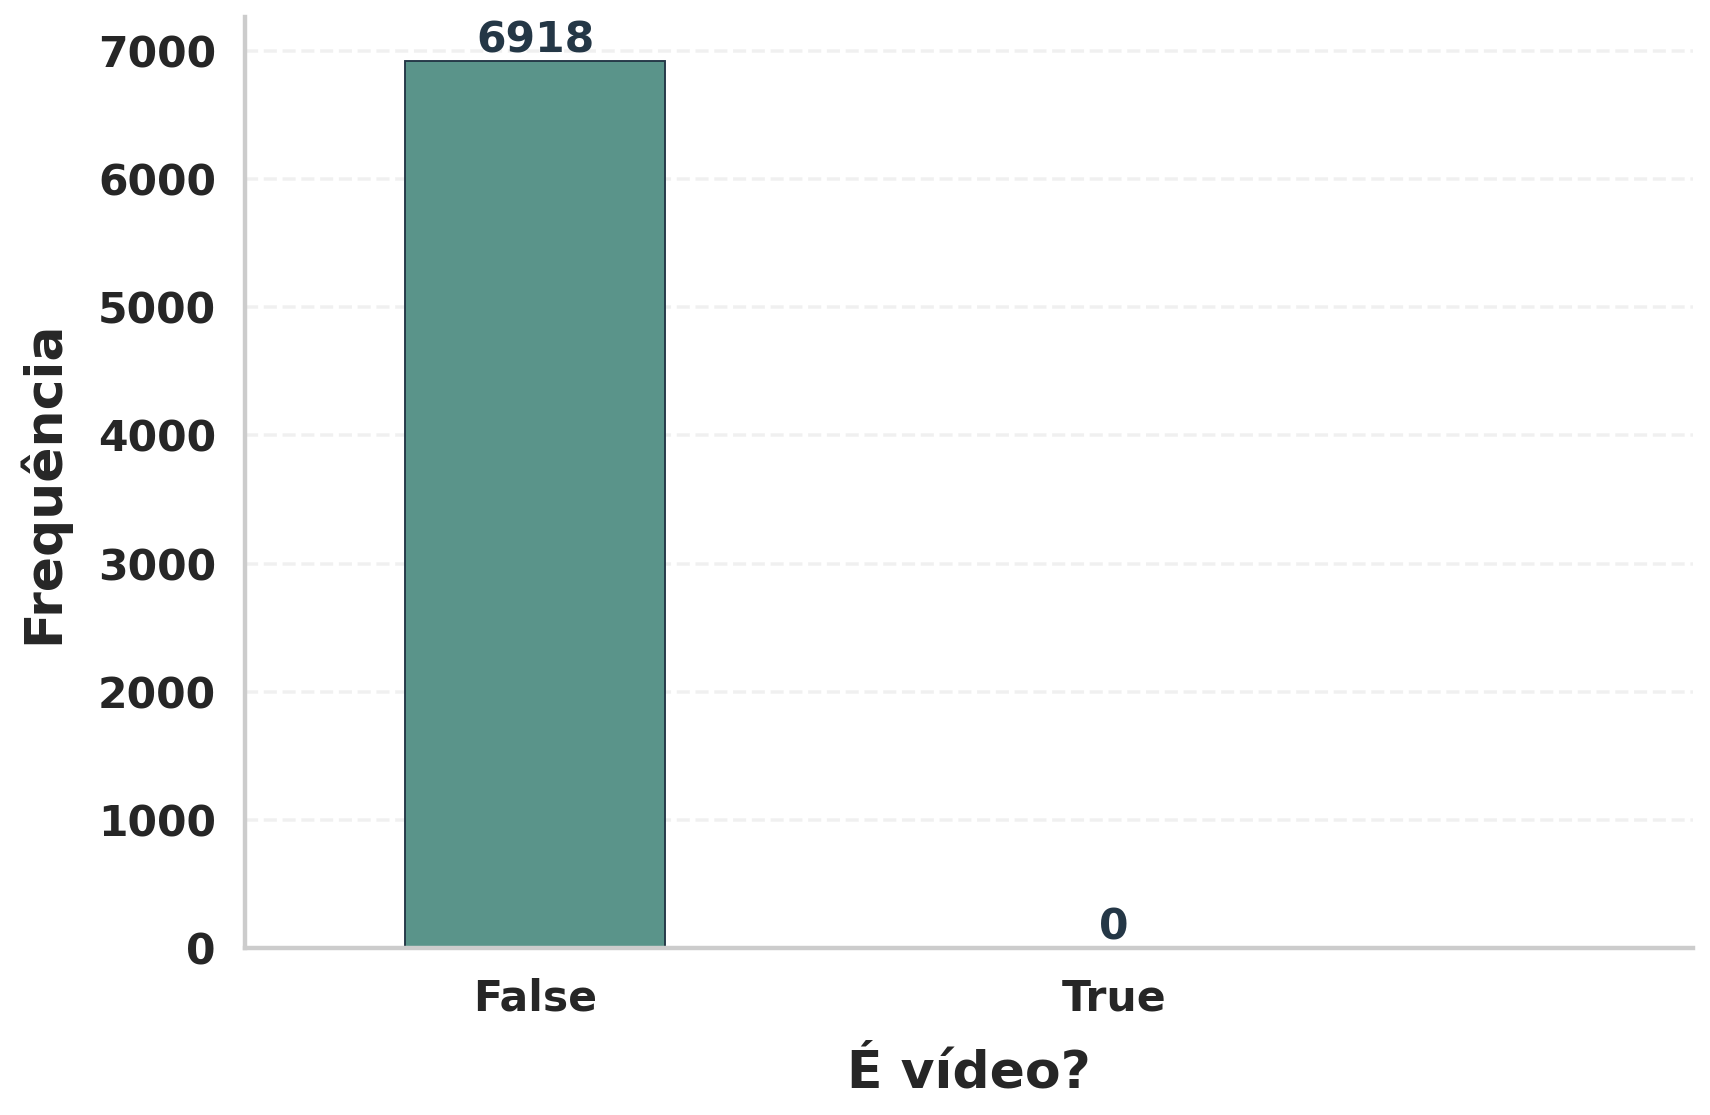

In [13]:
video_count = filtered_df['video'].value_counts().reindex([False, True], fill_value=0).reset_index()
video_count.columns = ['É vídeo?', 'Frequência']

plot_value_counts(video_count, 'É vídeo?', 'Distribuição de Vídeos')

## **Atributo: genres**

Os gêneros são analisados para identificar quais categorias aparecem com mais frequência no conjunto. Como um mesmo filme pode pertencer a mais de um gênero, essa etapa também ajuda a entender a composição temática da base de forma mais detalhada e a antecipar possíveis correlações entre perfil narrativo e desempenho comercial.


Figura: Frequência dos Gêneros de Filmes


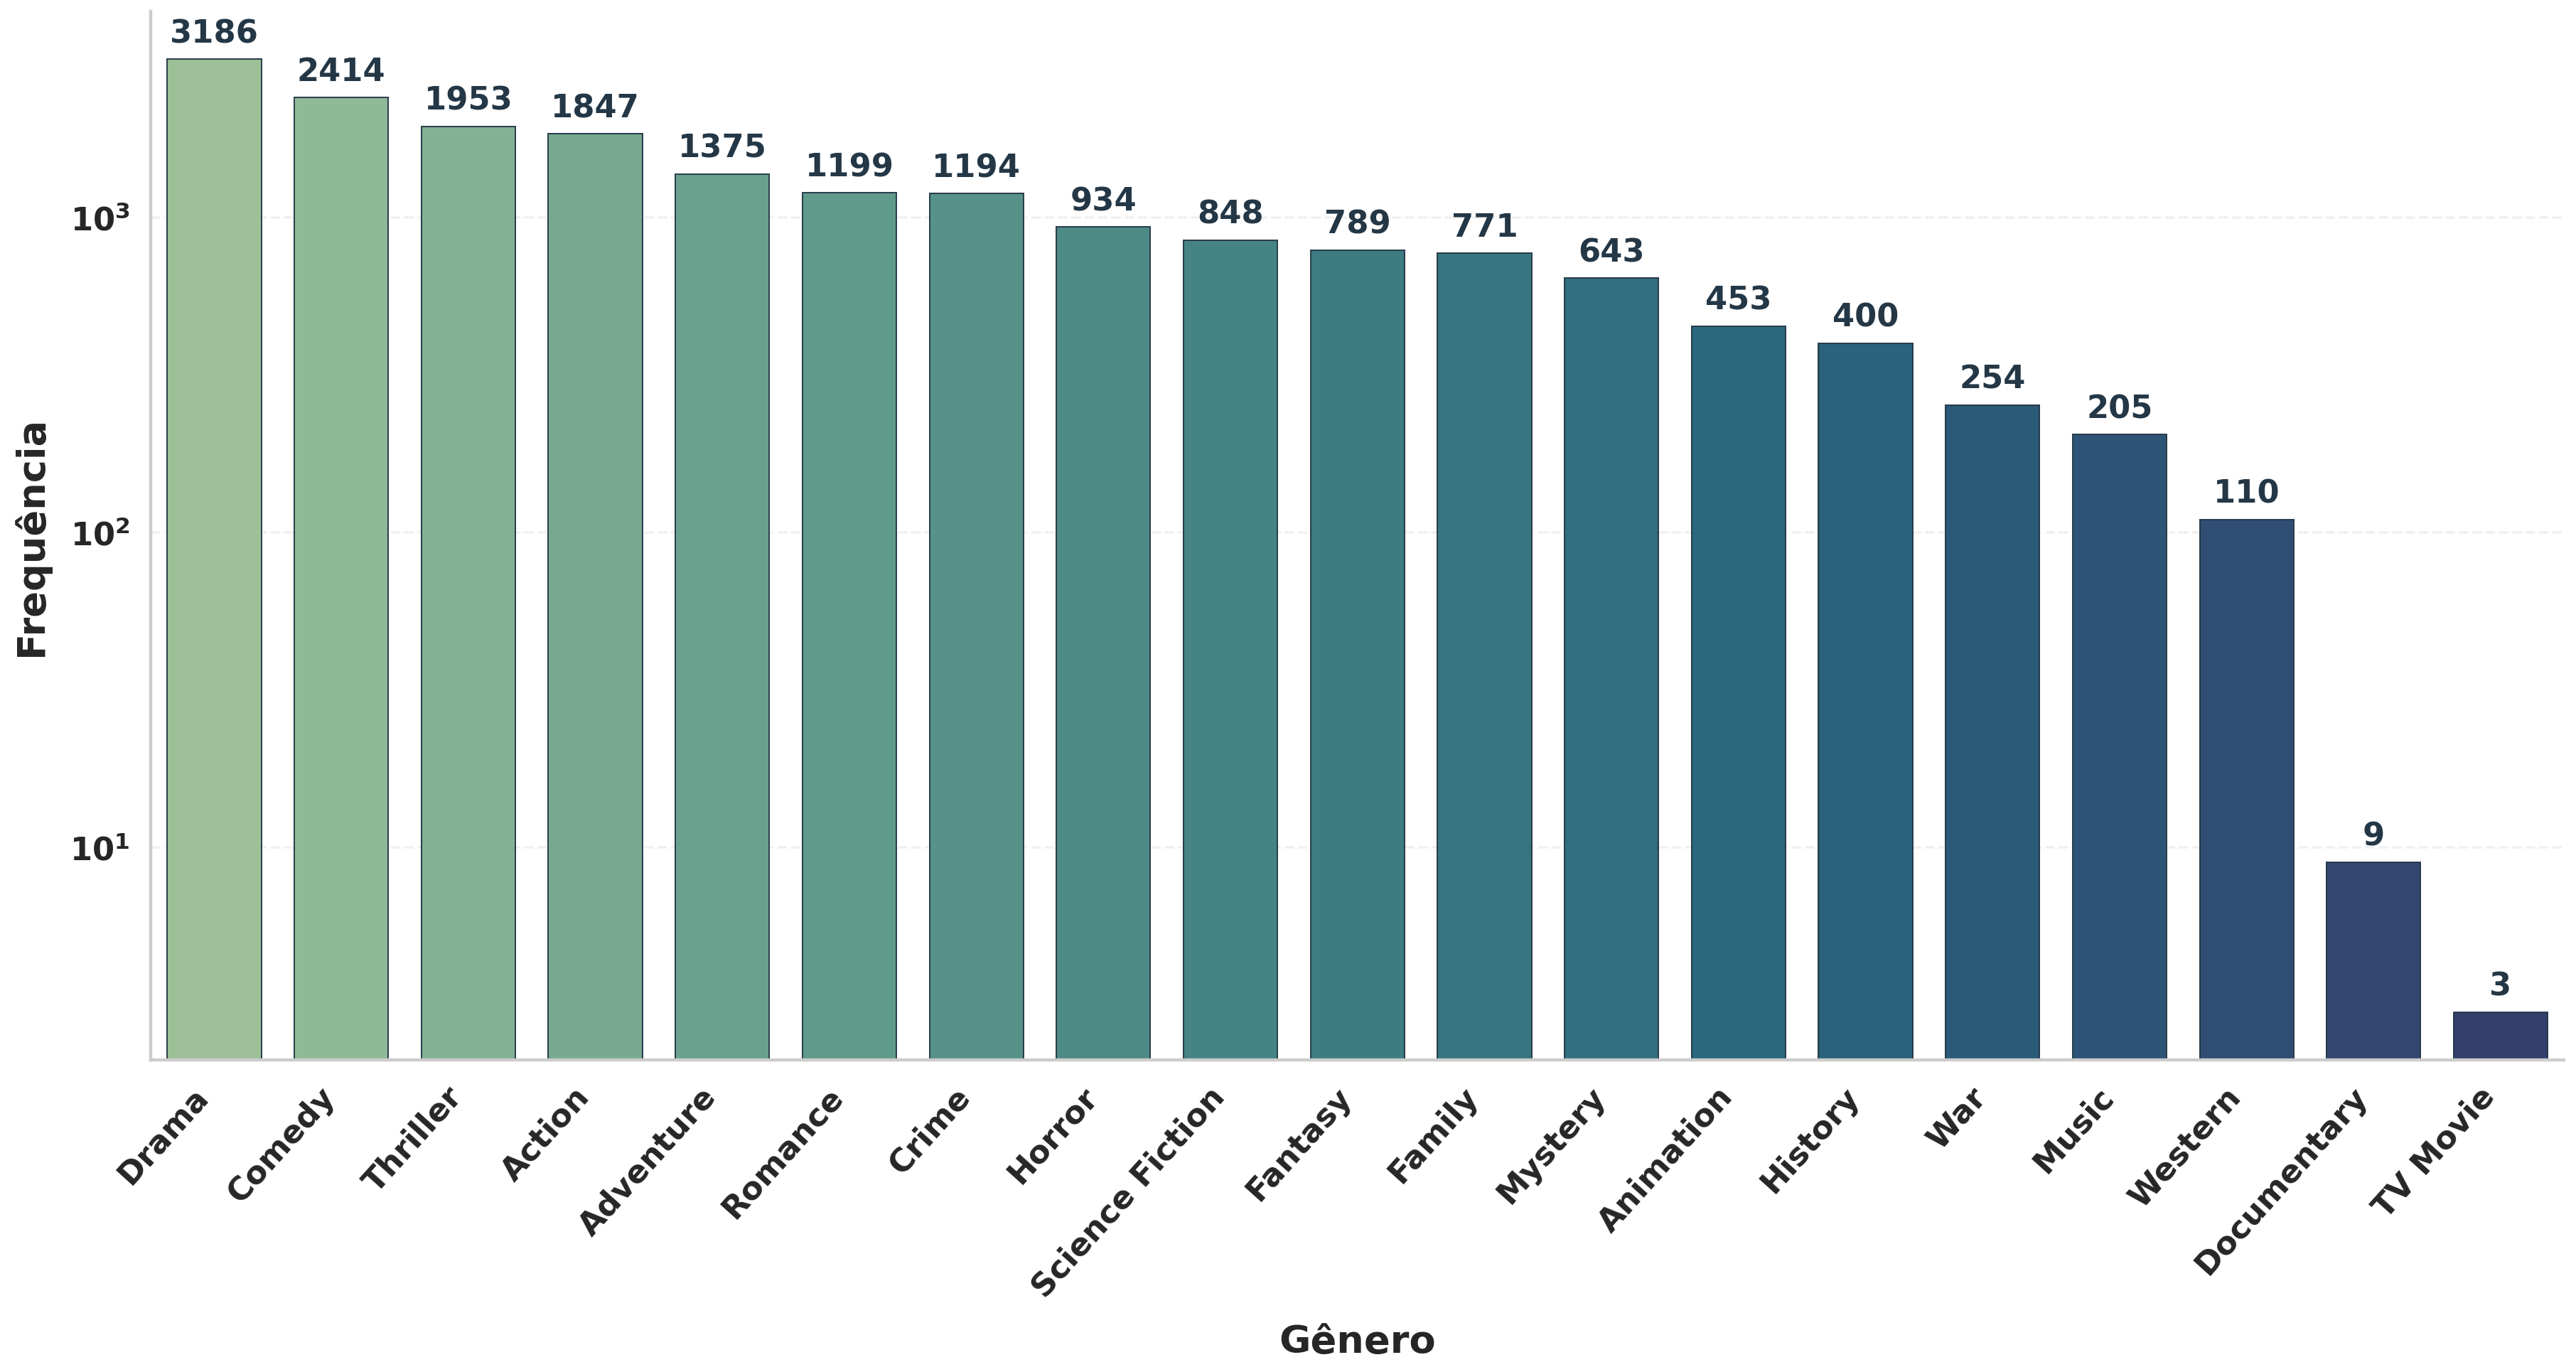

In [14]:
all_genres = [genre['name'] for genre_list in filtered_df['genres'] for genre in genre_list]
genre_counts = Counter(all_genres)
genre_counts = pd.DataFrame(genre_counts.items(), columns=['Gênero', 'Frequência'])
genre_counts = genre_counts.sort_values(by='Frequência', ascending=False)

plot_value_counts(genre_counts, 'Gênero', 'Frequência dos Gêneros de Filmes')

## **Atributo: status**

O atributo `status` descreve a situação de lançamento de cada obra. Como a base já foi restringida a títulos com status `Released`, essa análise funciona principalmente como uma verificação de consistência do conjunto final.


Figura: Distribuição dos Status dos Filmes


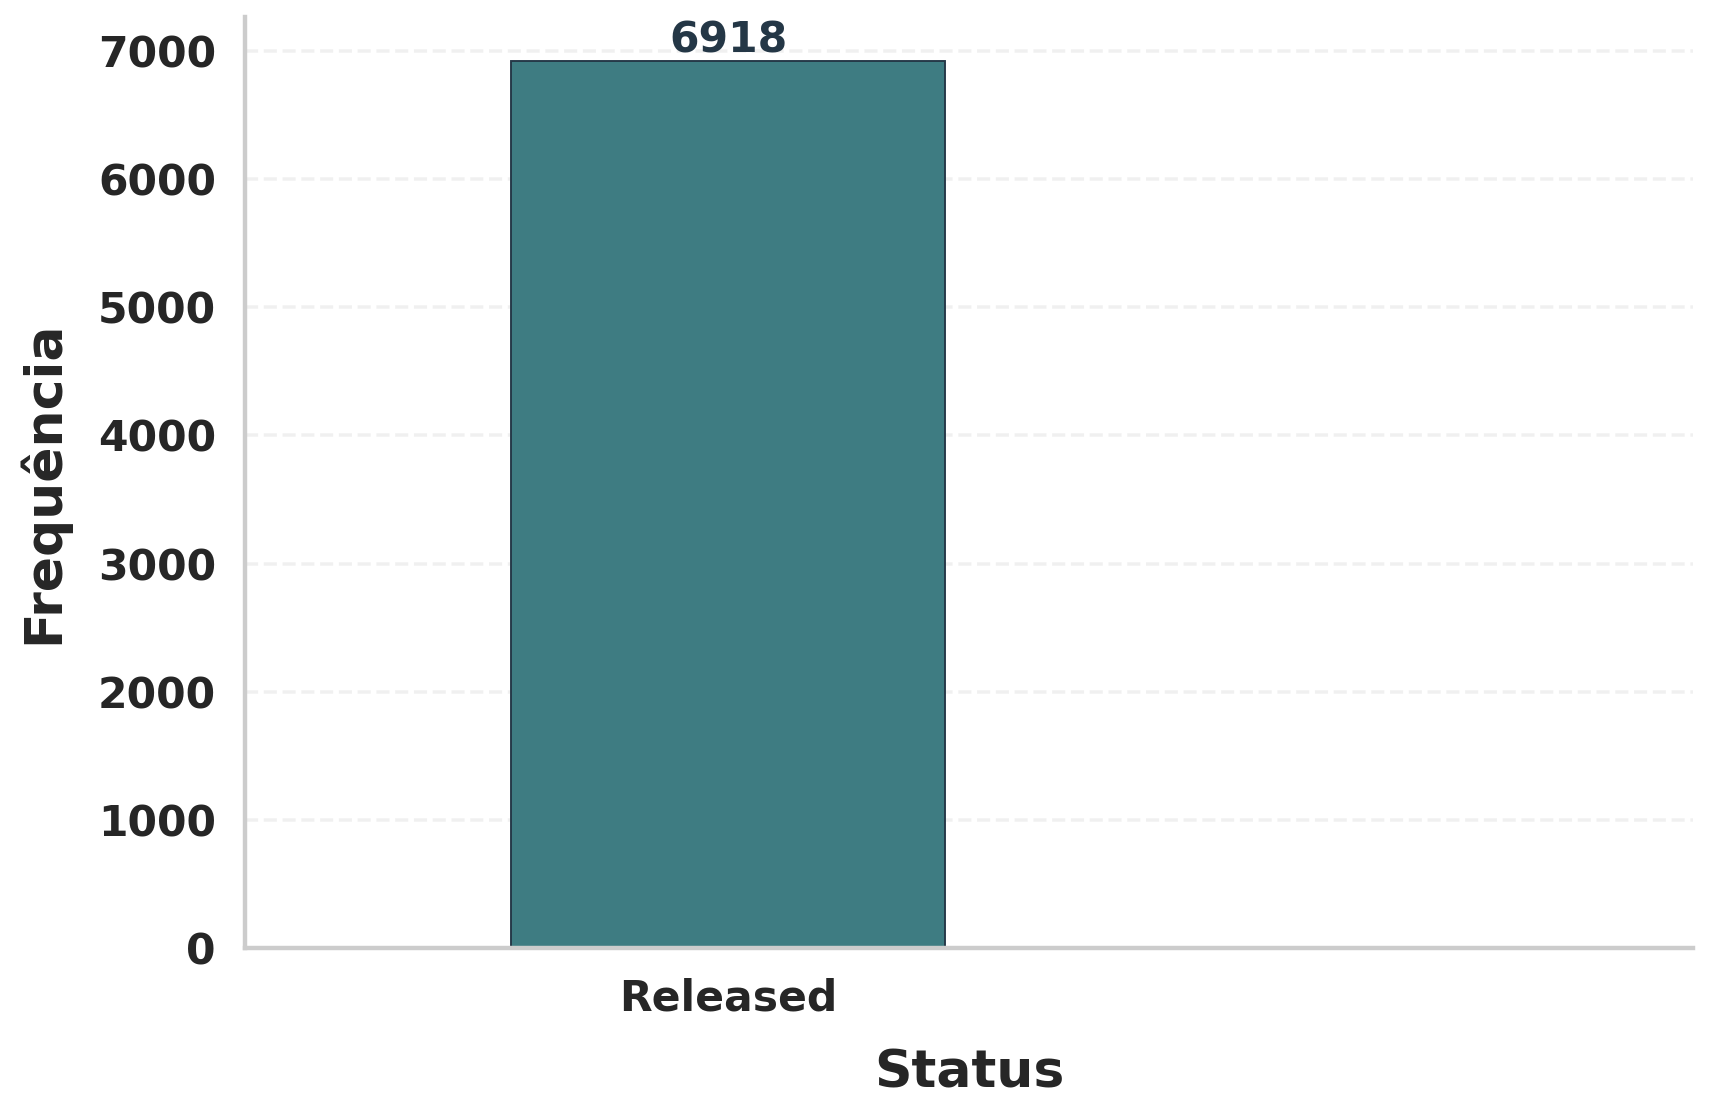

In [15]:
status_count = filtered_df['status'].value_counts().reset_index()
status_count.columns = ['Status', 'Frequência']

plot_value_counts(status_count, 'Status', 'Distribuição dos Status dos Filmes')

## **Atributo: belongs_to_collection**

Aqui é analisado se os filmes pertencem ou não a alguma coleção ou franquia. Essa informação pode ser relevante para o problema de regressão, já que produções ligadas a séries conhecidas podem apresentar comportamento comercial distinto em relação a títulos independentes.


Figura: Distribuição de Filmes que Pertencem a uma Coleção


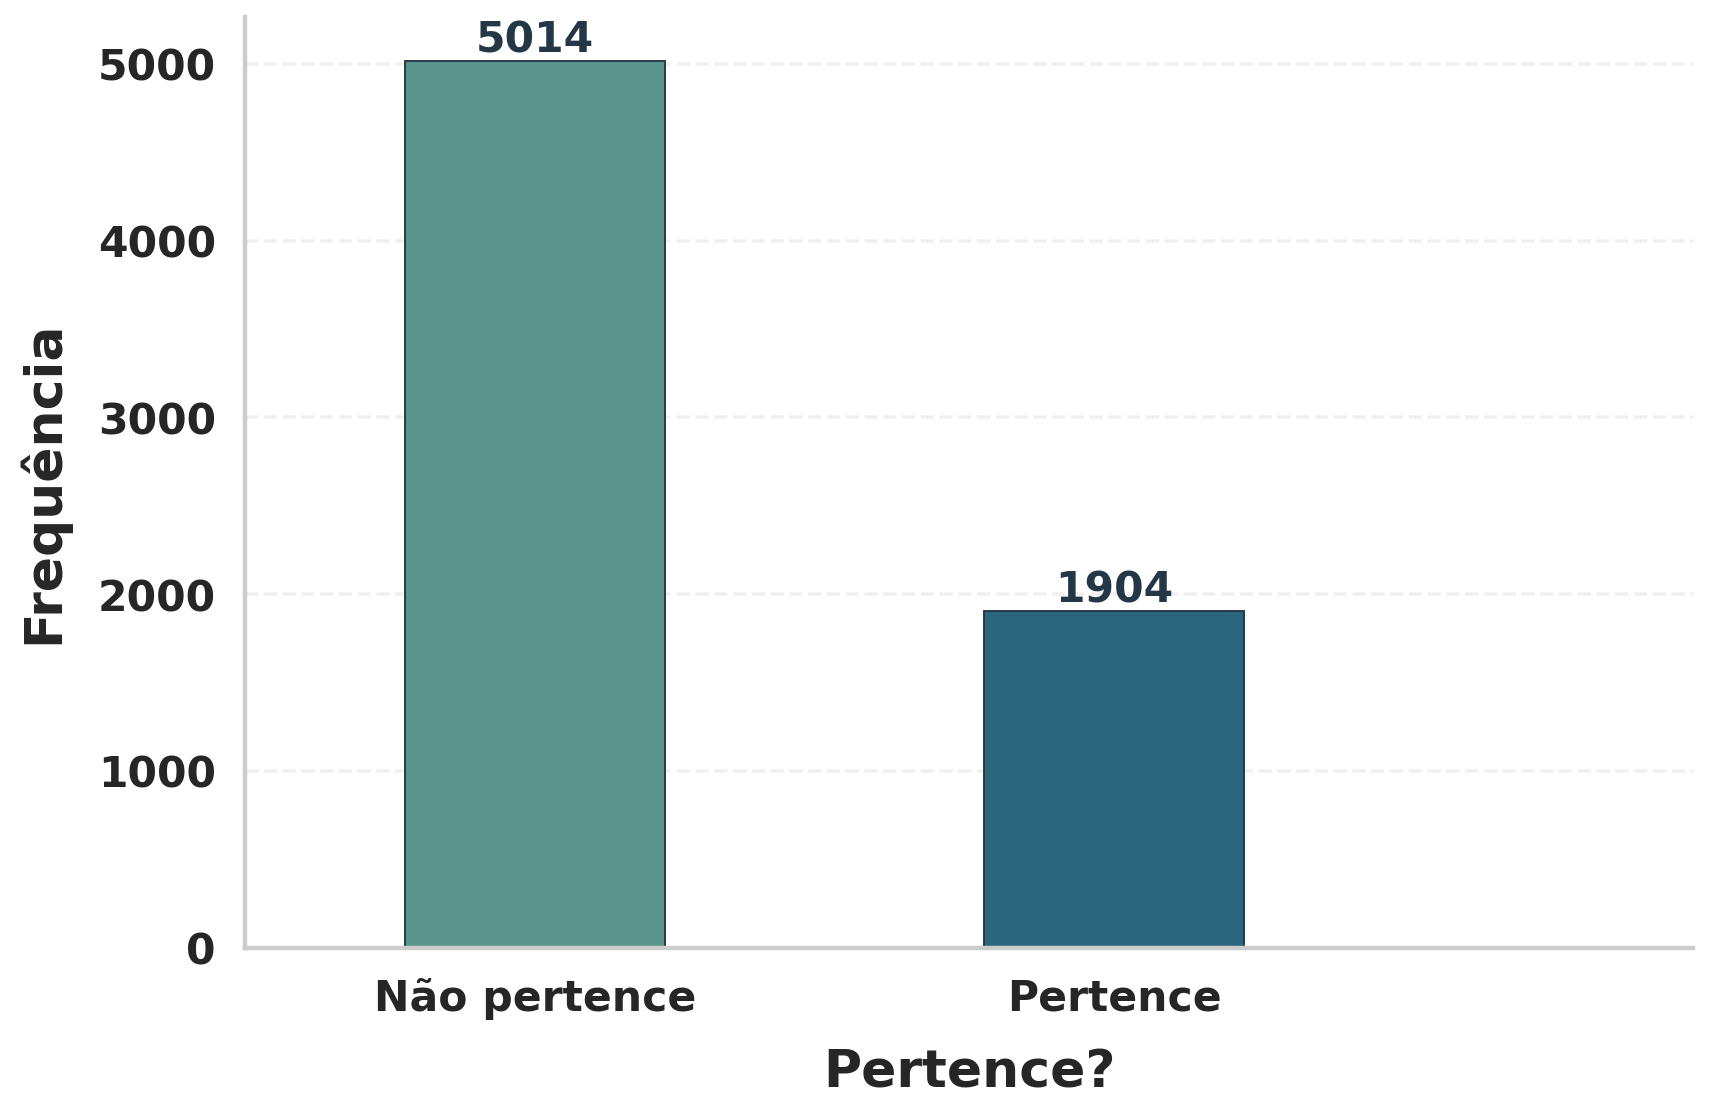

In [16]:
collections_count = filtered_df['belongs_to_collection'].apply(lambda x: 1 if x is not None else 0)
collections_count = collections_count.value_counts().reset_index()
collections_count.columns = ['Pertence?', 'Frequência']
collections_count['Pertence?'] = collections_count['Pertence?'].map({0: 'Não pertence', 1: 'Pertence'})

plot_value_counts(collections_count, 'Pertence?', 'Distribuição de Filmes que Pertencem a uma Coleção')

## **Atributo: runtime**

A duração dos filmes é tratada como uma variável numérica contínua. Por isso, além de estatísticas descritivas, são observados boxplots e distribuições para compreender a dispersão dos valores, a presença de possíveis extremos e a faixa em que a maior parte das produções se concentra.


,count,mean,std,min,25%,50%,75%,max
Estatísticas da Duração,6918.0,110.90821,21.224175,5.0,96.0,107.0,121.0,254.0


Figura: Boxplot da Duração dos Filmes


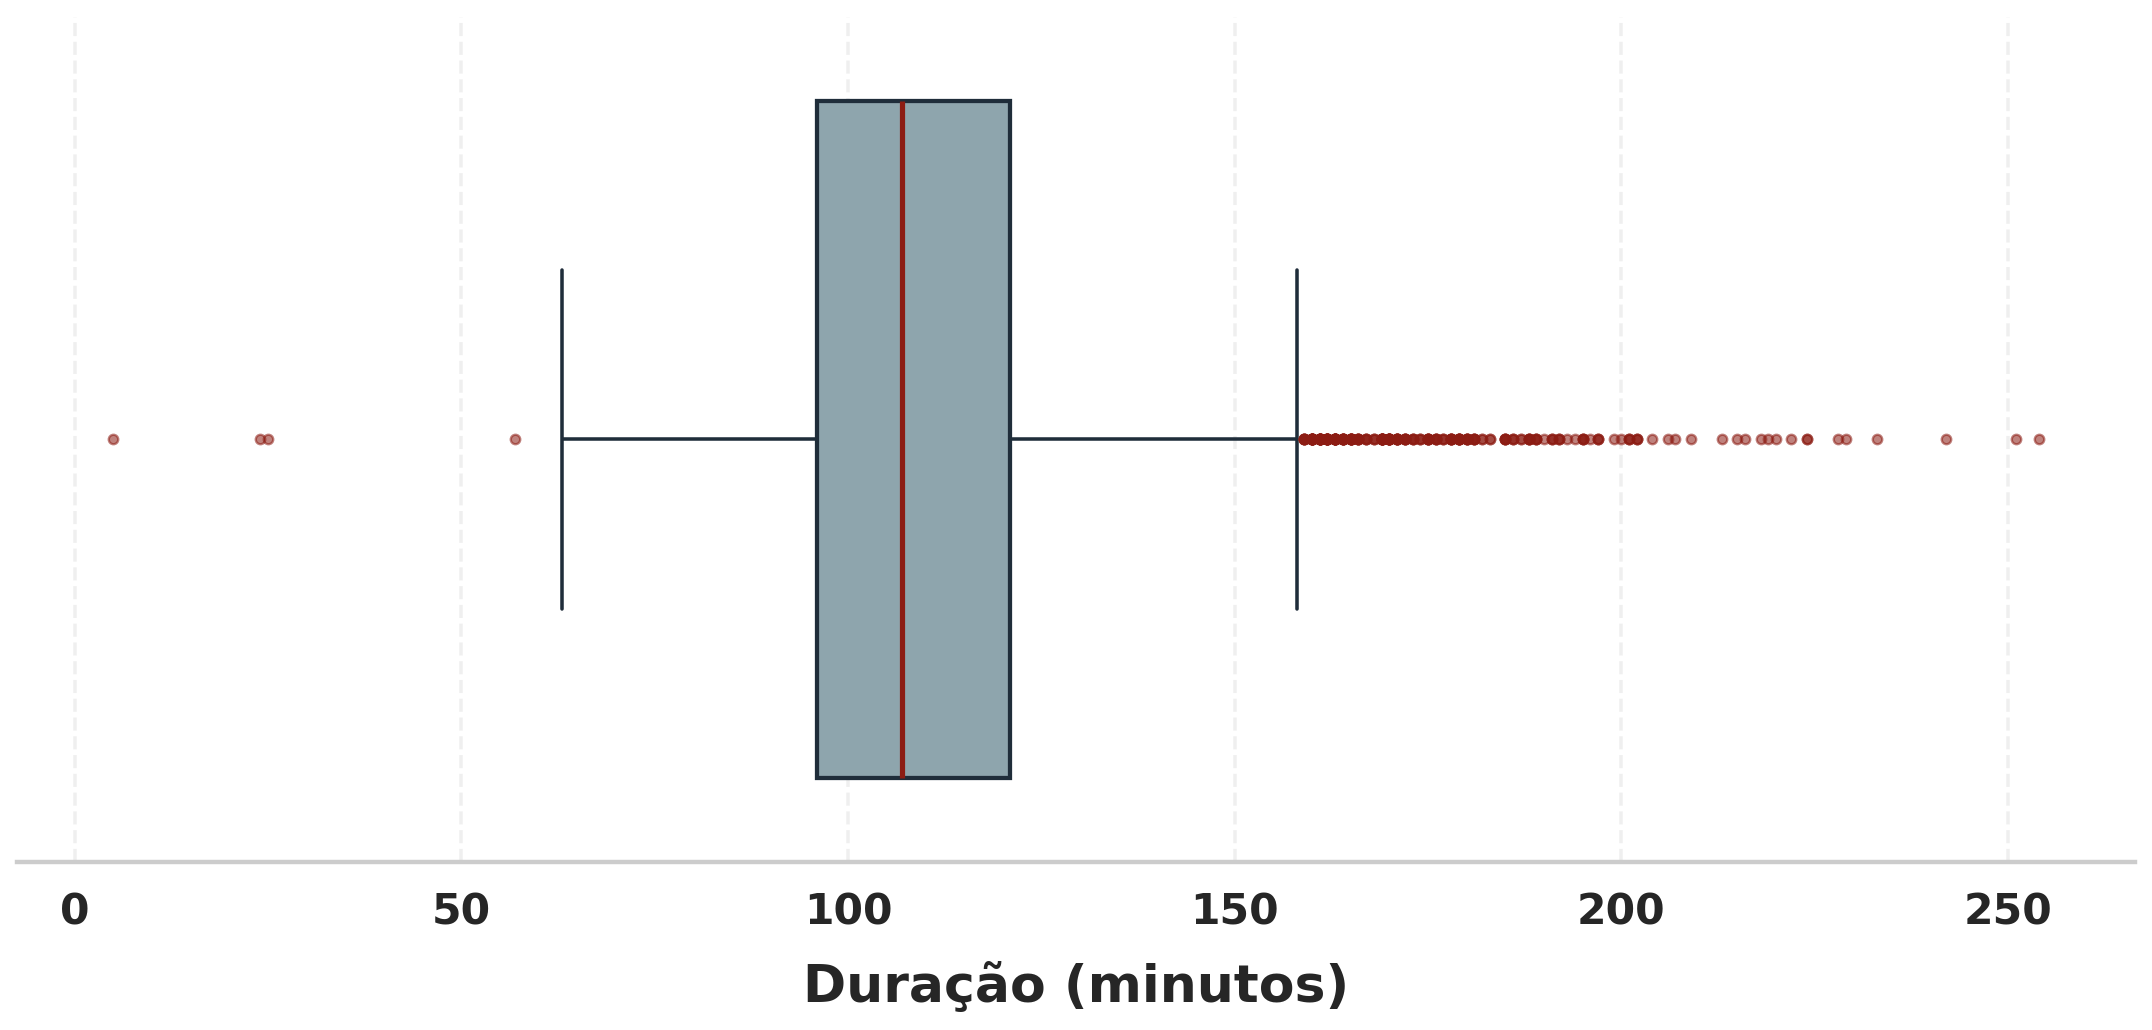

In [17]:
desc = describe_column(filtered_df, 'runtime', 'Estatísticas da Duração')
display(desc)

plot_boxplot(filtered_df, 'runtime', 'Boxplot da Duração dos Filmes', 'Duração (minutos)')

Figura: Distribuição da Duração dos Filmes


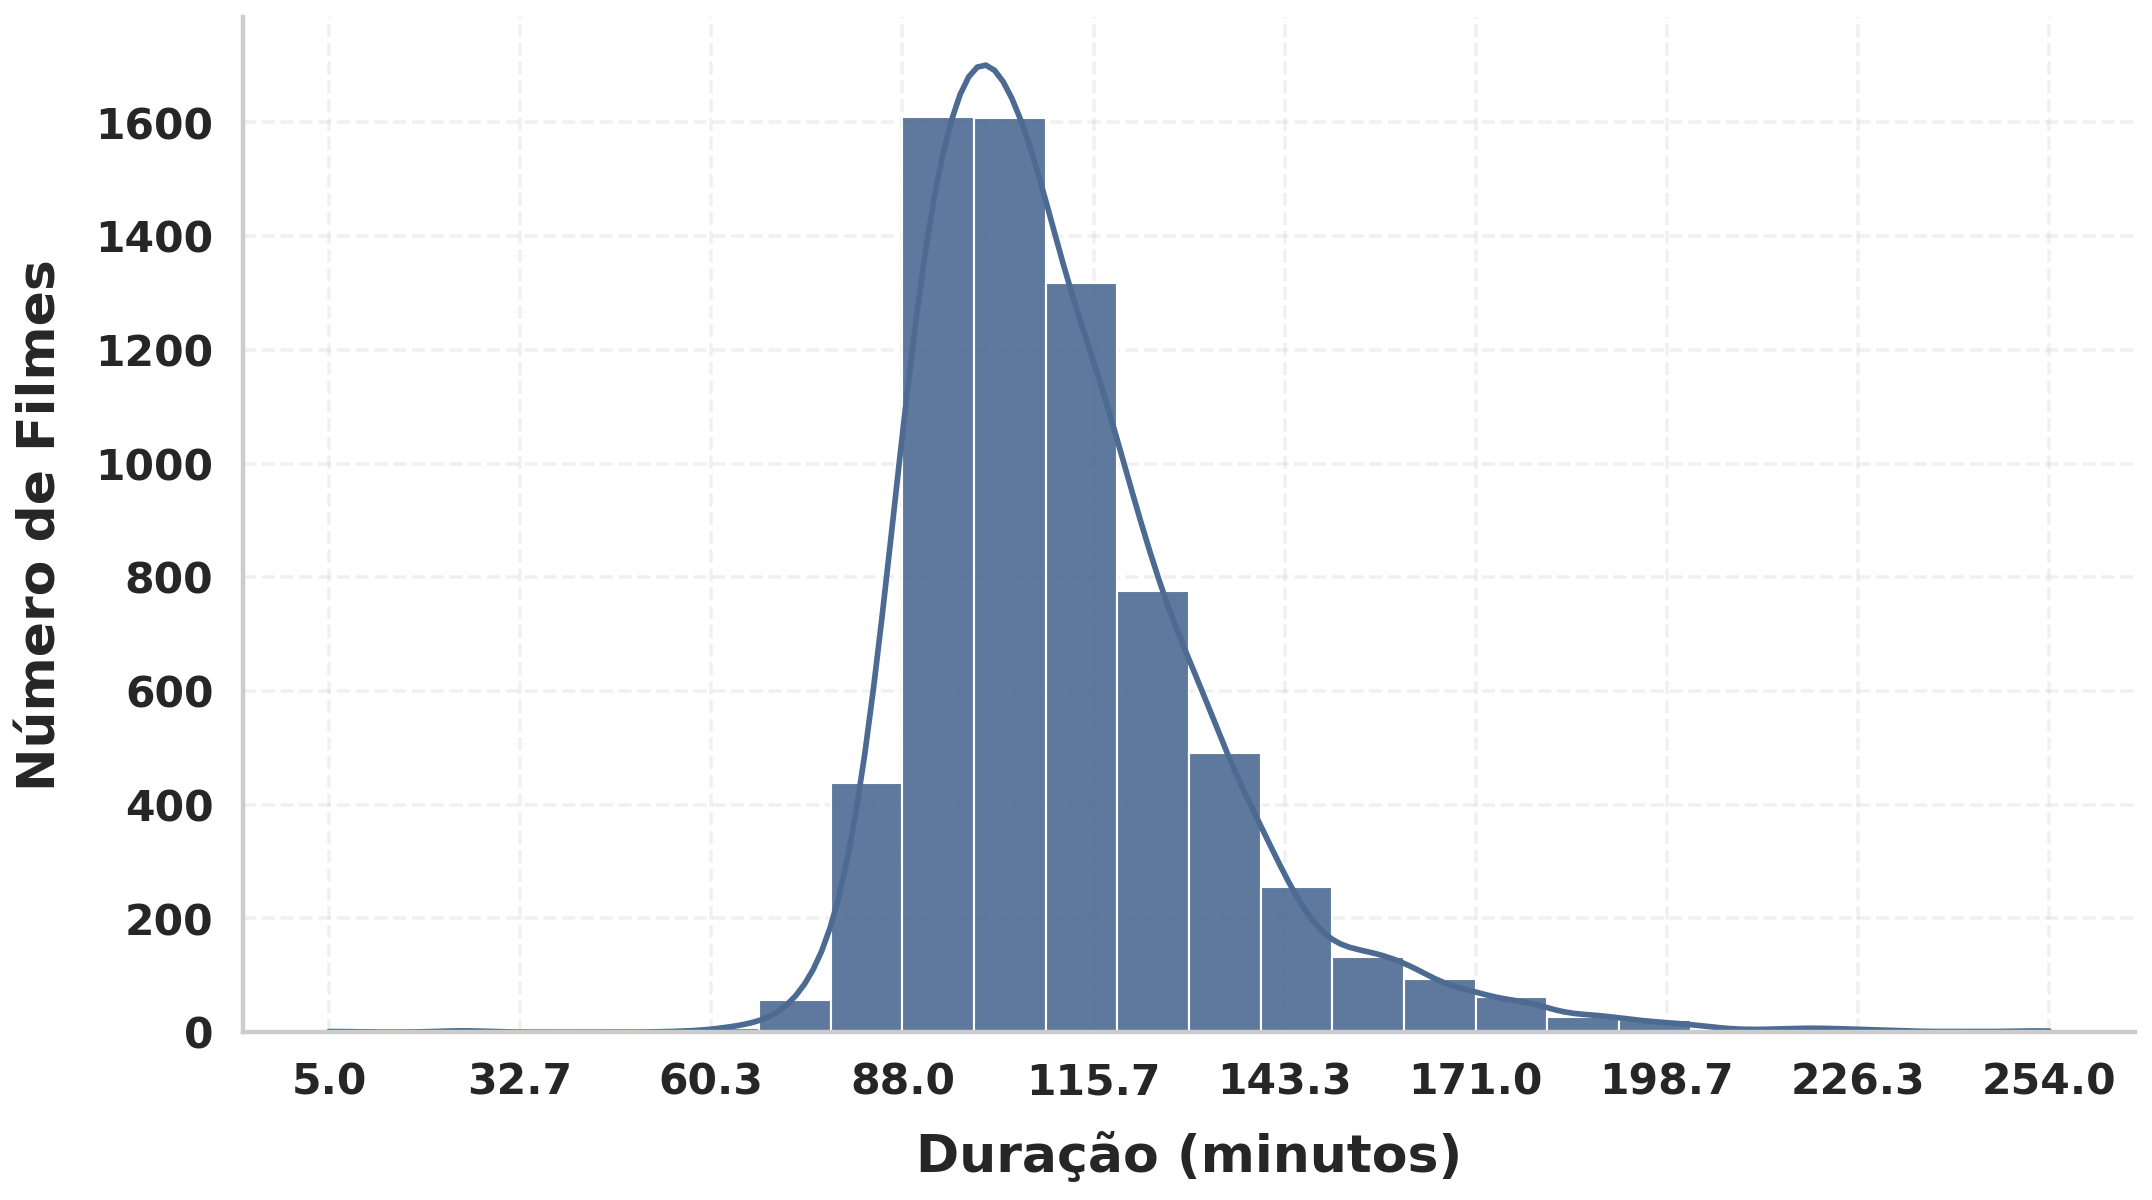

In [18]:
plot_distribution(filtered_df, 'runtime', 'Distribuição da Duração dos Filmes', 'Duração (minutos)')

## **Atributo: budget**

O orçamento é uma das variáveis numéricas mais relevantes para o problema estudado. Sua análise exploratória ajuda a entender a escala dos investimentos presentes na base, bem como a assimetria e a concentração dos valores, aspectos que influenciam diretamente a dificuldade do problema preditivo.


,count,mean,std,min,25%,50%,75%,max
Estatísticas do Orçamento,6918.0,3.391299e+07,4.420884e+07,1.0,7000000.0,19000000.0,40000000.0,465400000.0


Figura: Boxplot do Orçamento dos Filmes


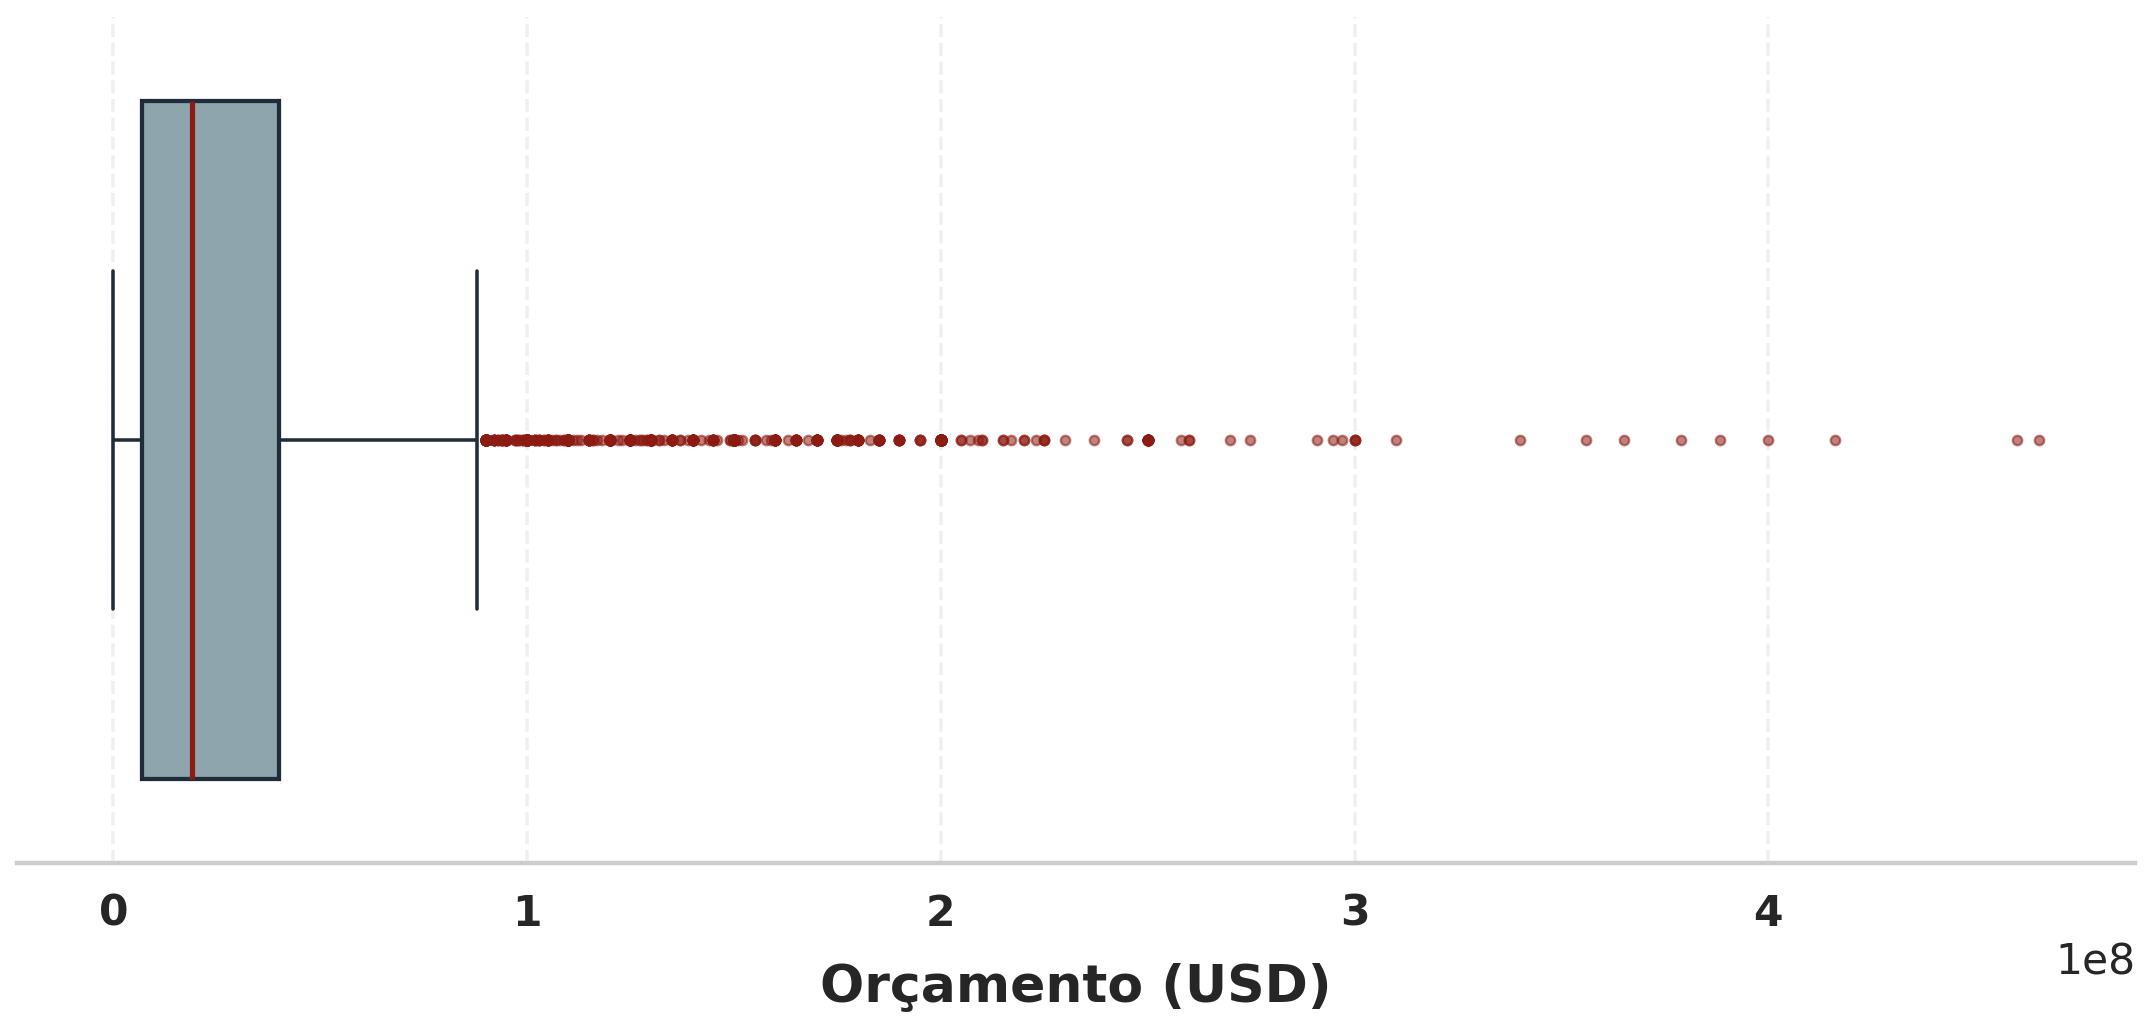

In [19]:
desc = describe_column(filtered_df, 'budget', 'Estatísticas do Orçamento')
display(desc)

plot_boxplot(filtered_df, 'budget', 'Boxplot do Orçamento dos Filmes', 'Orçamento (USD)')

Figura: Distribuição do Orçamento dos Filmes


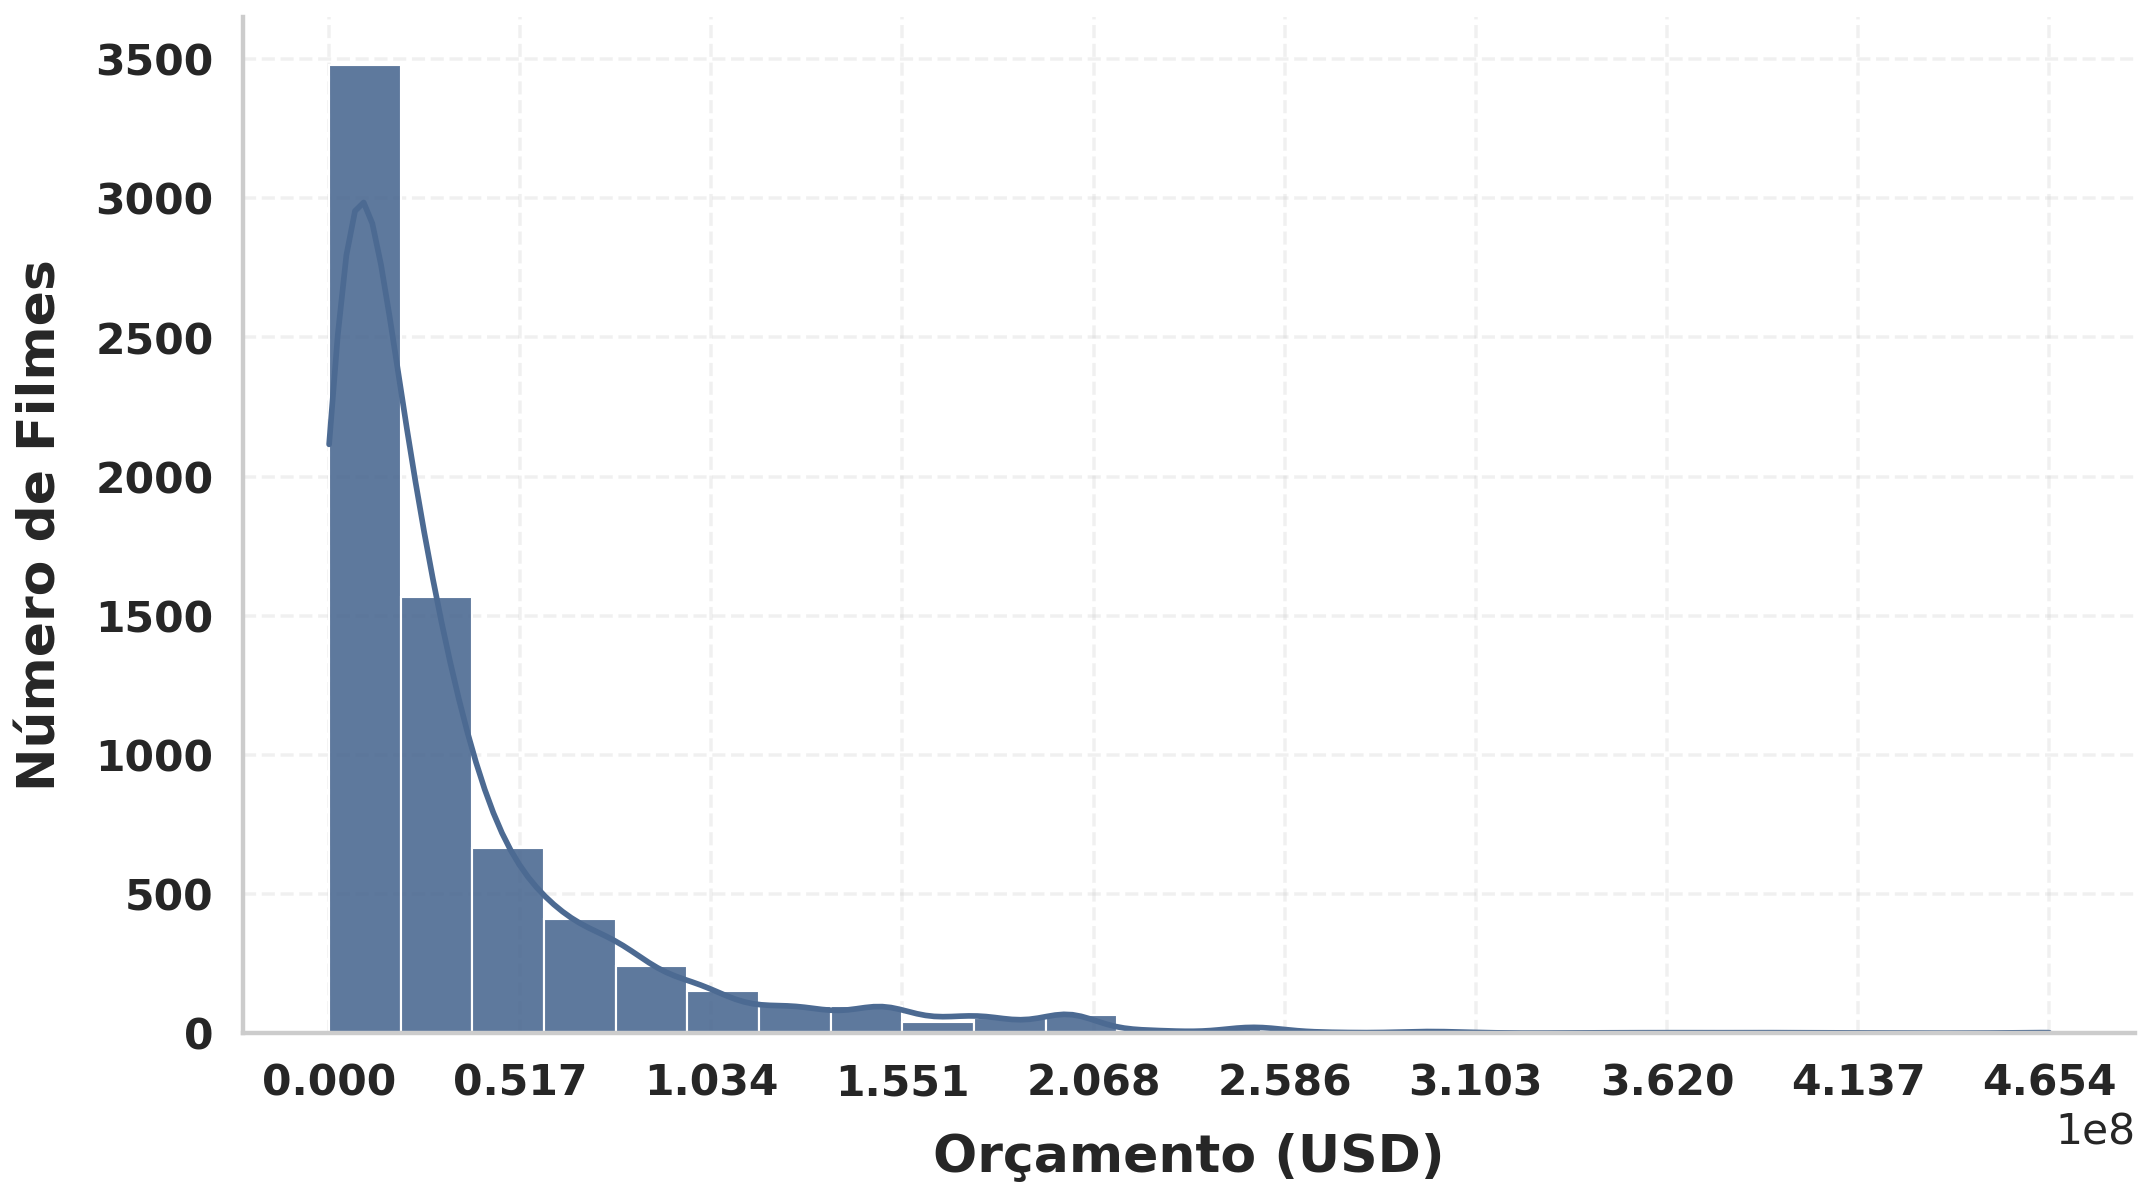

In [20]:
plot_distribution(filtered_df, 'budget', 'Distribuição do Orçamento dos Filmes', 'Orçamento (USD)')

## **Atributo: revenue**

A receita corresponde à variável-alvo do problema de regressão. Examinar sua distribuição é essencial para entender o comportamento dos valores que o modelo precisará prever, incluindo sua dispersão, a assimetria da cauda superior e a presença de filmes com arrecadações muito acima da média.


,count,mean,std,min,25%,50%,75%,max
Estatísticas da Receita,6918.0,9.901634e+07,1.858709e+08,1.0,10300000.0,35157940.0,103995009.5,2.923706e+09


Figura: Boxplot da Receita dos Filmes


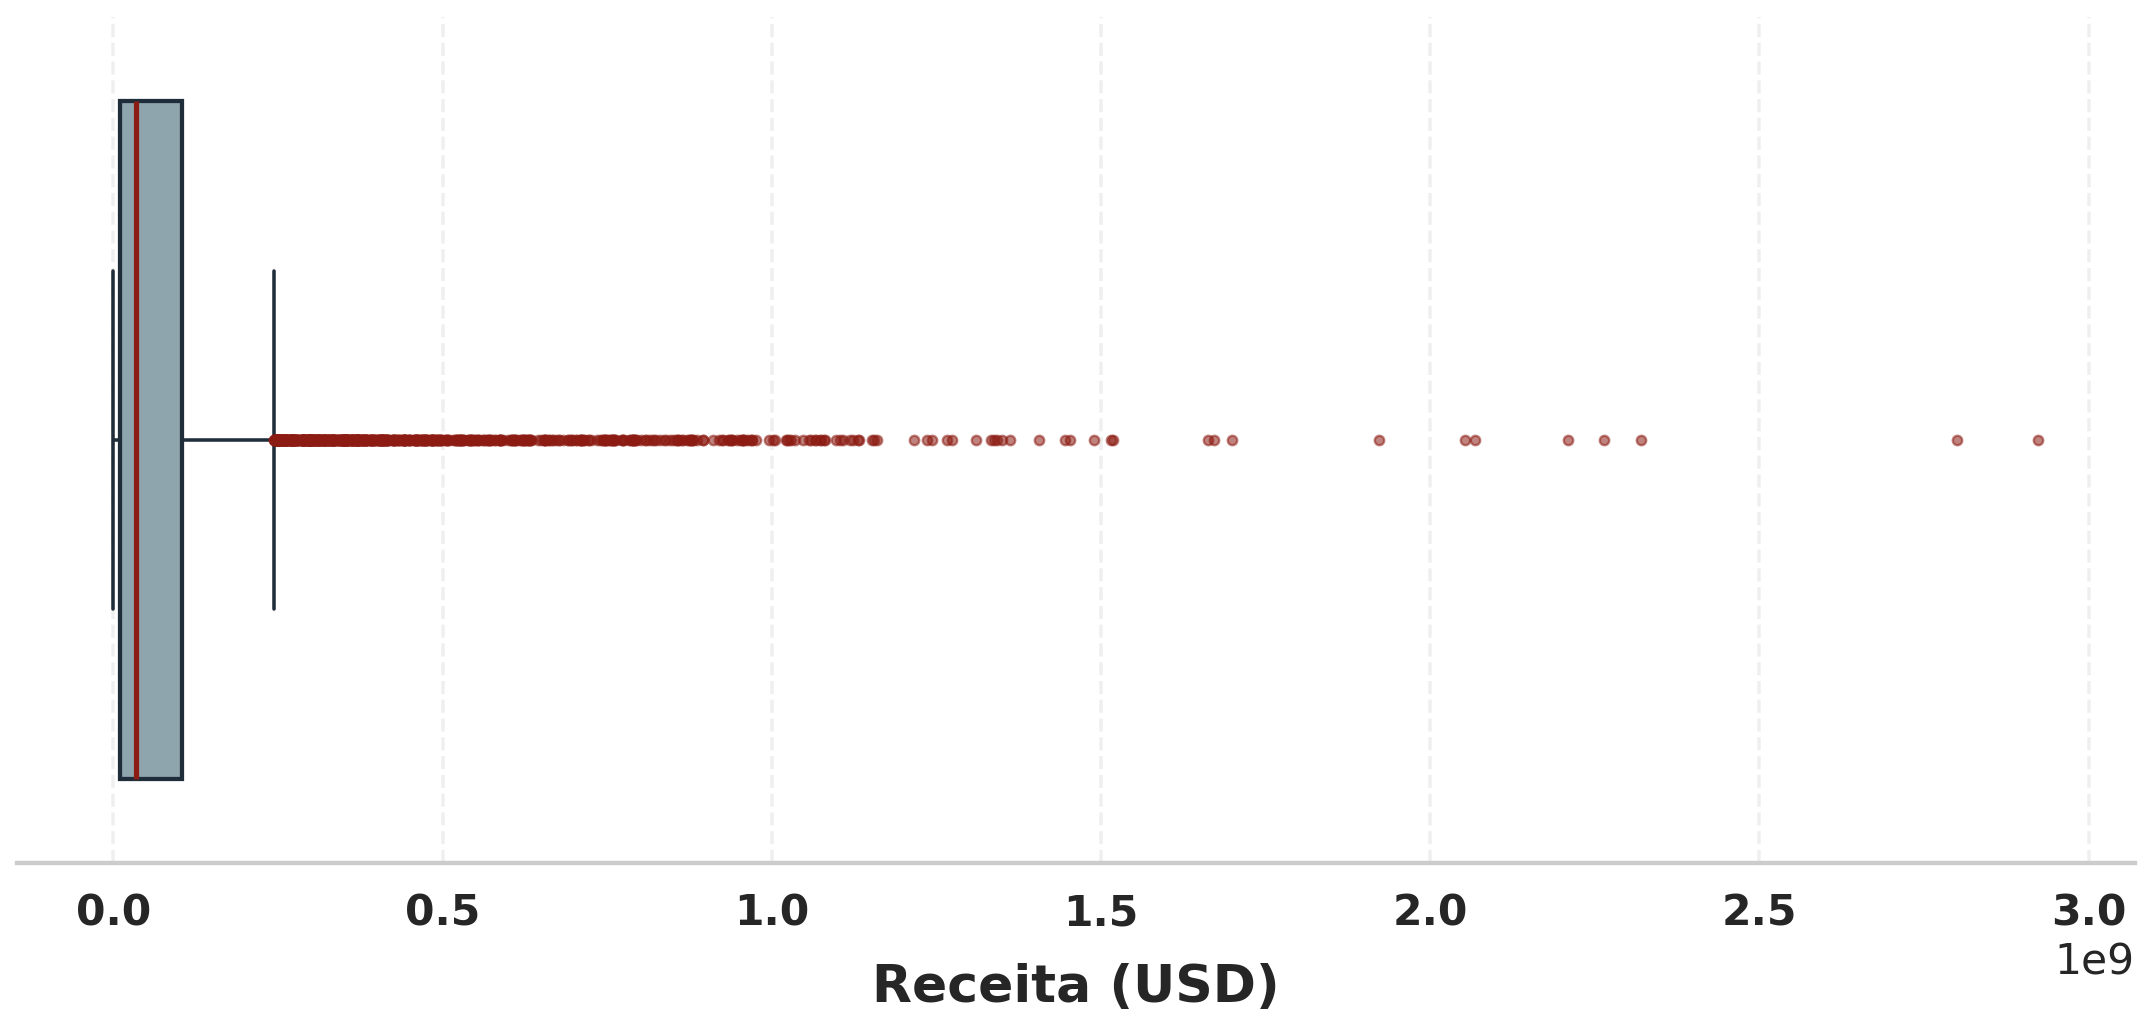

In [21]:
desc = describe_column(filtered_df, 'revenue', 'Estatísticas da Receita')
display(desc)

plot_boxplot(filtered_df, 'revenue', 'Boxplot da Receita dos Filmes', 'Receita (USD)')

Figura: Distribuição da Receita dos Filmes


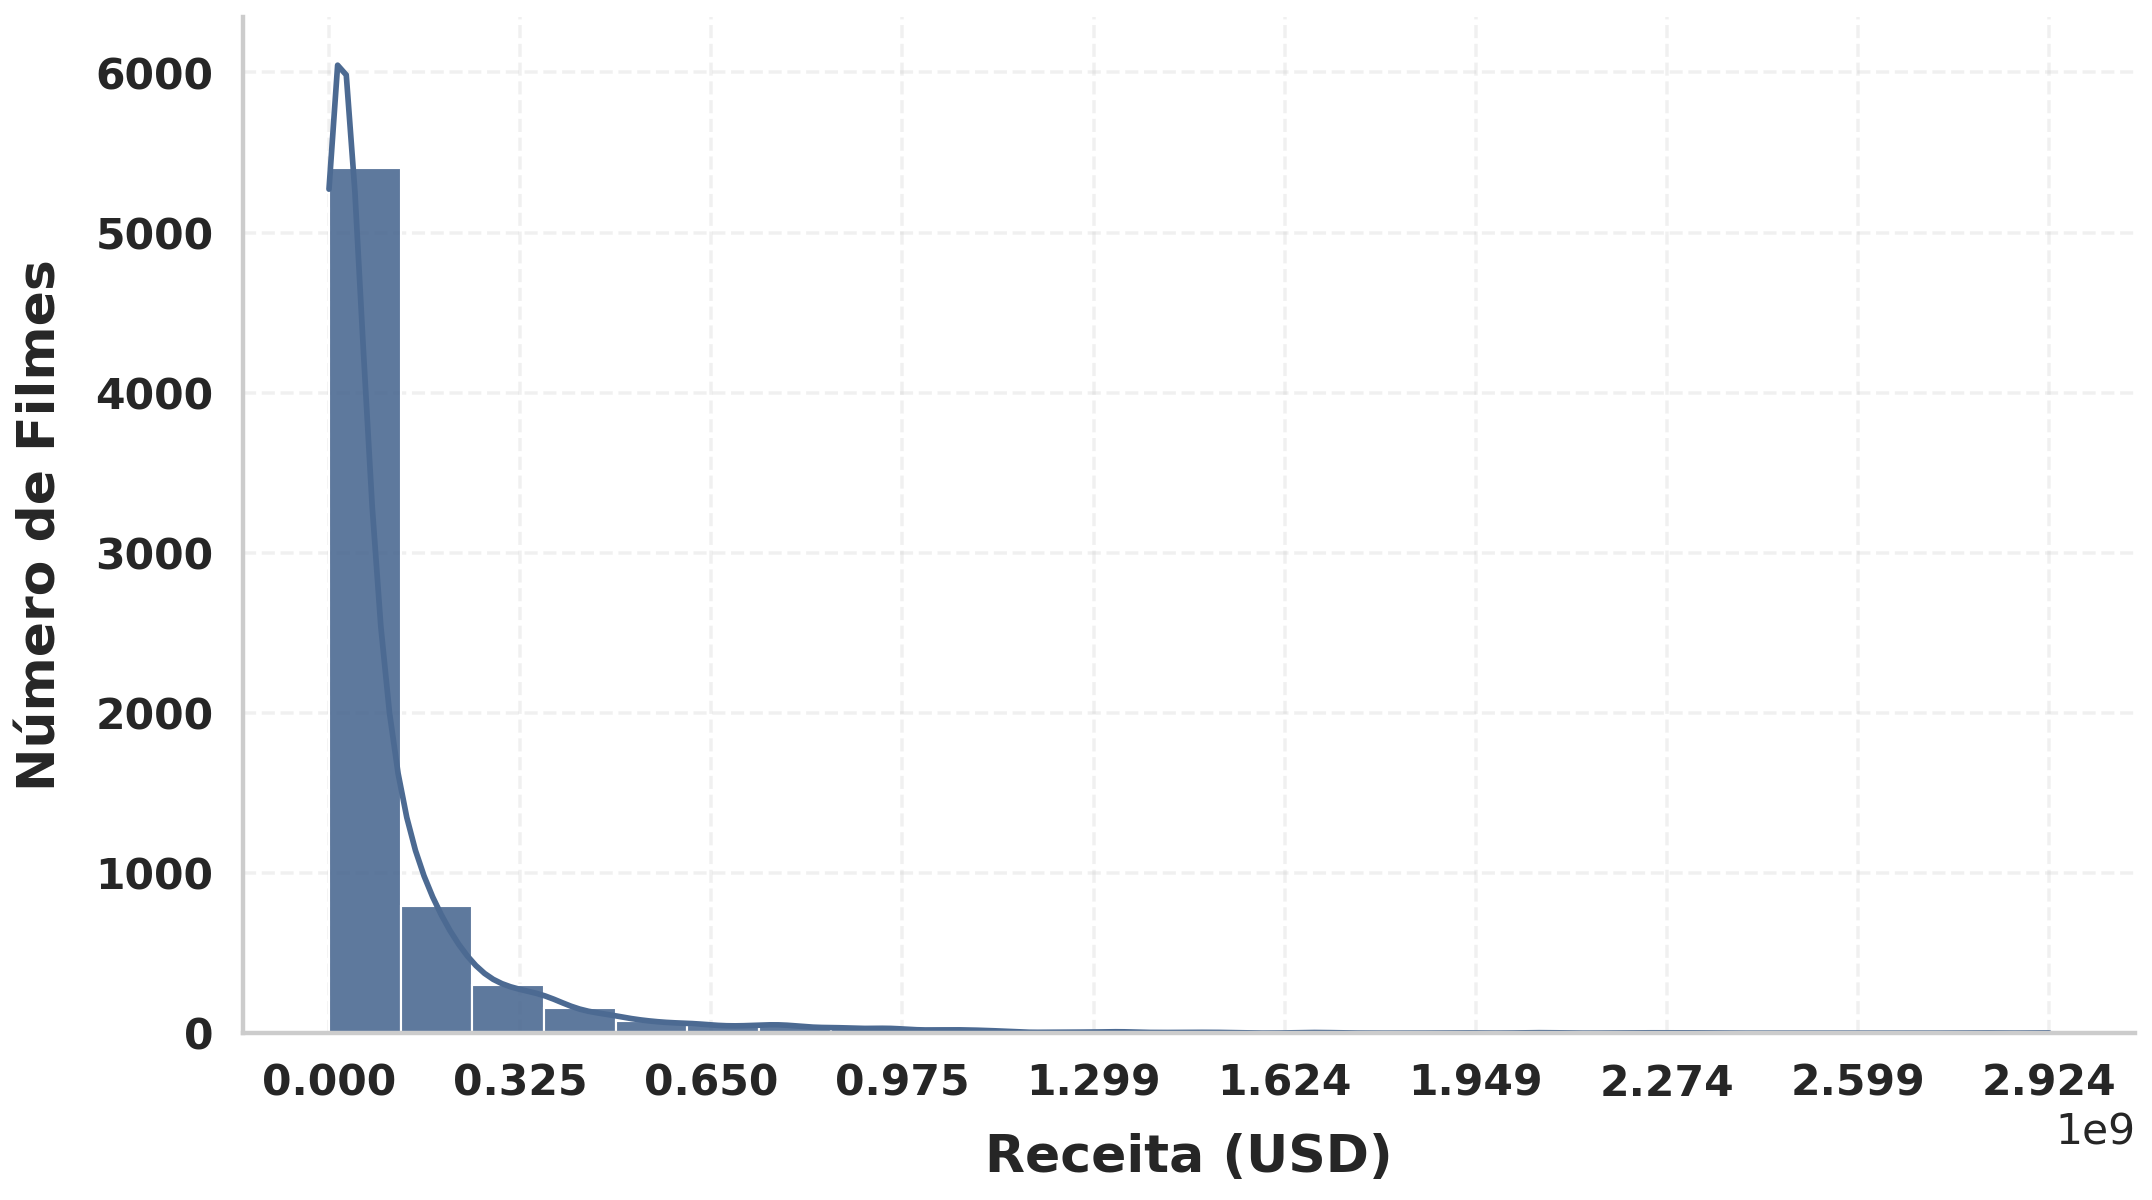

In [22]:
plot_distribution(filtered_df, 'revenue', 'Distribuição da Receita dos Filmes', 'Receita (USD)')

# **Processando o dataset a fim de realizar a regressão**

Depois da análise exploratória, a base é transformada para a etapa de modelagem. O objetivo agora é selecionar os atributos de interesse, padronizar representações categóricas e binárias e deixar o conjunto final em um formato adequado para os algoritmos de regressão.

A preocupação central nesta etapa é tornar o dataset utilizável pelos modelos sem perder interpretabilidade nem introduzir vazamento de informação entre treino e teste.


## **Selecionando colunas relevantes**

Nesta etapa, são mantidas apenas as variáveis consideradas úteis para a tarefa de predição de receita. Permanecem no conjunto os campos de identificação, alguns atributos numéricos e categóricos de interesse e a variável-alvo `revenue`, enquanto colunas já descartadas conceitualmente nas etapas anteriores deixam de participar do conjunto final.

Essa redução ajuda a manter o problema focado em atributos com valor explicativo plausível e evita carregar para a modelagem campos redundantes ou pouco informativos.


In [23]:
filtered_df = filtered_df[['id_tmdb', 'title', 'runtime', 'adult', 'belongs_to_collection', 'genres', 'original_language', 'budget', 'revenue']]

## **Transformando os dados da coluna `belongs_to_collection` em dados booleanos**

Como o interesse principal aqui não é o conteúdo completo da coleção, mas apenas saber se o filme pertence ou não a alguma franquia, a coluna `belongs_to_collection` é convertida em um indicador binário. Assim, cada filme passa a receber `1` quando pertence a uma coleção e `0` caso contrário.

Essa simplificação preserva a informação mais relevante para o problema e evita uma representação textual pouco prática para os modelos de regressão.


In [24]:
filtered_df.loc[:, 'belongs_to_collection'] = filtered_df['belongs_to_collection'].apply(lambda x: 1 if x is not None else 0)
filtered_df['belongs_to_collection'].value_counts()

belongs_to_collection
0    5014
1    1904
Name: count, dtype: int64

## **Transformando colunas booleanas em numéricas**

Algoritmos de regressão operam mais diretamente com variáveis numéricas. Por isso, o atributo `adult` é convertido de valores booleanos para uma representação binária, com `0` para `False` e `1` para `True`.

Mesmo quando a coluna apresenta pouca variação, manter esse tratamento explícito torna o pipeline mais coerente e facilita a reprodutibilidade.


In [25]:
filtered_df['adult'] = filtered_df['adult'].astype(int)
filtered_df['adult'].value_counts()

adult
0    6918
Name: count, dtype: int64

## **Preparação das colunas numéricas**

As colunas `budget`, `runtime` e `revenue` são mantidas em sua escala original no conjunto processado gerado por este notebook.

Nos experimentos de regressão, o escalonamento é aplicado apenas dentro do `pipeline` de treino de cada execução, por meio de `MinMaxScaler`, o que evita vazamento de informação entre treino e teste.

Essa separação entre dataset processado e transformação aplicada apenas no treinamento deixa a etapa de modelagem mais limpa e metodologicamente segura.


In [26]:
numeric_columns = ['budget', 'runtime', 'revenue']
filtered_df[numeric_columns].head()

,budget,runtime,revenue
0,100000000,108,610800000
1,150000000,101,947000000
2,23500000,133,24727058
3,50000000,110,229314062
4,40000000,116,98652557


## **Extração e codificação das informações de gênero**

A coluna `genres` originalmente armazena uma lista de dicionários para cada filme. Para que essa informação possa ser usada pelo modelo, primeiro são extraídos apenas os nomes dos gêneros presentes em cada obra; em seguida, essa representação textual é preparada para a criação de variáveis binárias.

Esse passo é necessário porque a estrutura original é informativa para leitura humana, mas inadequada para uso direto por algoritmos supervisionados tradicionais.


## **Transformação dos Gêneros em Variáveis Binárias**

Após a extração dos nomes dos gêneros, aplica-se uma codificação do tipo one-hot encoding com `MultiLabelBinarizer`. O resultado é a criação de uma coluna binária para cada gênero presente na base, indicando se ele aparece ou não em cada filme.

Como um título pode pertencer simultaneamente a vários gêneros, esse tipo de codificação é mais adequado do que uma representação categórica simples com um único rótulo por filme.


In [27]:
filtered_df['genres'] = filtered_df['genres'].apply(lambda x: [d['name'] for d in x] if isinstance(x, list) else [])

mlb = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(
    mlb.fit_transform(filtered_df['genres']),
    columns=mlb.classes_,
    index=filtered_df.index
)

filtered_df = pd.concat([filtered_df, genre_dummies], axis=1)
filtered_df.drop(columns=['genres'], inplace=True)

## **Transformação da Coluna `original_language` em Variáveis Binárias**

A coluna `original_language` também é convertida para uma representação numérica por meio de one-hot encoding. Dessa forma, cada idioma passa a ser representado por uma coluna binária, permitindo que o modelo utilize essa informação categórica sem perda de interpretabilidade.

Essa escolha evita impor uma ordem artificial entre idiomas e mantém a leitura das variáveis consistente com o significado original do atributo.


In [28]:
mlb = MultiLabelBinarizer()
original_language_dummies = pd.DataFrame(
    mlb.fit_transform(filtered_df['original_language'].apply(lambda x: [x])),
    columns=mlb.classes_,
    index=filtered_df.index
)

filtered_df = pd.concat([filtered_df, original_language_dummies], axis=1)
filtered_df.drop(columns=['original_language'], inplace=True)

## **Reorganizando as colunas do dataset**

Por fim, as colunas são reorganizadas para deixar a variável-alvo `revenue` na última posição do `DataFrame`. Essa organização não altera os dados em si, mas facilita a leitura do conjunto final e a separação entre variáveis preditoras e variável-resposta nas etapas seguintes.

O resultado é um dataset processado que já está pronto para ser consumido pelos notebooks de validação e seleção de modelos.


In [29]:
cols = [col for col in filtered_df.columns if col != 'revenue']
cols.append('revenue')
filtered_df = filtered_df[cols]
filtered_df

,id_tmdb,title,runtime,adult,belongs_to_collection,budget,Action,Adventure,Animation,Comedy,...,sv,ta,te,th,tn,tr,uk,ur,zh,revenue
0,552524,Lilo & Stitch,108,0,0,100000000,0,0,0,1,...,0,0,0,0,0,0,0,0,0,610800000
1,950387,A Minecraft Movie,101,0,1,150000000,0,1,0,1,...,0,0,0,0,0,0,0,0,0,947000000
2,1257960,सिकंदर,133,0,0,23500000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,24727058
3,574475,Final Destination Bloodlines,110,0,1,50000000,0,0,0,0,...,0,0,0,0,0,0,0,0,0,229314062
4,1197306,A Working Man,116,0,0,40000000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,98652557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19987,12211,Highlander: Endgame,87,0,1,25000000,1,1,0,0,...,0,0,0,0,0,0,0,0,0,15843608
19988,590706,Jiu Jitsu,102,0,0,23000000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,99924
19989,459616,Alad'2,98,0,1,18900000,0,1,0,1,...,0,0,0,0,0,0,0,0,0,19000000
19994,188207,The Legend of Hercules,99,0,0,70000000,1,1,0,0,...,0,0,0,0,0,0,0,0,0,61279452


In [30]:
filtered_df.to_csv(PROJECT_ROOT / 'data' / 'TMDB_movies_processed.csv', index=False)